# FP-Cox Optimizer — SaDE v21 (FP Shift + Scaling, SaDE Memory Fix)

Self-Adaptive Differential Evolution for Fractional Polynomial Cox model selection.

**Objective:** Pure BIC minimisation (no penalizer).

---

## Changes in v21 (over v20)

### Parallel memory (OOM) fix in `run_simulation_study`
- `_bootstrap_one_iteration` is dispatched as a **bound method**, so loky pickles the entire `FPCoxOptimizer` into every worker. After `optimize()` that object carries five fitted models, four design frames and the main-run caches — none of which the workers read (they rebuild everything from `self.df`).
- Added `__getstate__` / `__setstate__` to **strip that heavy state from the pickle payload**. This shrinks both each per-worker copy and the parent-side dispatch buffer (loky pre-pickles ~2x n_jobs tasks ahead). The optimizer in the main session keeps all attributes — only pickling is affected.
- Removed the dead `del` + `gc.collect()` block at the end of `_bootstrap_one_iteration`: those names are function-locals freed on return, and the repeated `CoxPHFitter` fits leave no leak or reference cycles for `gc` to reclaim (RSS is flat across thousands of fits).
- `n_jobs` set to 4 on the example runs. The remaining lever if memory is still tight is **fewer workers** — each loky process pays a fixed ~150 MB import baseline, so total memory falls roughly linearly with `n_jobs`.

## Changes in v19 (over v17)

### FP-required preprocessing restored
- Each covariate is **shifted to strictly positive** (Royston-Sauerbrei FP shift) so that log and negative or fractional powers are defined. A notice lists every shift applied, and inputs containing NaN/Inf now raise an error instead of silently degrading.
- Each covariate is then **scaled by a power of ten** for numerical stability. Scaling is magnitude-only and leaves deviance, BIC, C-index and IBS unchanged.
- **Pre-logging:** covariates may be passed already log-transformed (e.g. to tame skew). FP is then applied to log(x), and the positivity shift is what keeps those columns valid. This is a deliberate, documented modelling choice.

### SaDE strategy-memory fix
- Success/failure memory now stores **per-generation counts over the last LP generations** (fixed-length deques) instead of clipping successes and failures independently. The strategy-probability and CR-median updates now follow the trailing-LP-generation window intended by the Qin-Suganthan scheme.

### Boundary repair by reflection
- Out-of-range power indices now **reflect** off the bounds, so extreme powers no longer wrap around to the None/drop code at index 0. (Residual limitation: None still sits next to the most negative power on the ordinal index axis.)

### Other
- `MFPSelector` gained a `verbose` flag; per-bootstrap MFP fits run silently during validation.
- Stratification removed from all example runs.
- Out-of-bag validation prints a **paired** comparison (FP vs MFP, FP vs Cox) on the shared holdout, and bootstrap percentile ranges are labelled as spread, not confidence intervals.
- The bootstrap procedure is described as **internal validation**, not a simulation study.

## Changes in v16 (over v15)

### Removed: Internal preprocessing / scaling
- `_preprocess_positive()` has been **removed entirely**.
- The optimizer now takes the data **as-is** — all log transforms, skewness corrections,
  and positive-shift operations must be done upstream (in the EDA notebook).
- `self._scales` is removed; FP transforms operate on the raw covariate values passed in.
- **Important**: All covariates must be **strictly positive** before being passed to the optimizer,
  since FP powers include negative exponents and `log(x)`. This is the caller's responsibility.

### Removed: Cross-validated IBS (`IBS_cv`)
- `_compute_cv_ibs()` has been **removed**.
- The bootstrap simulation already provides out-of-bag (OOB) IBS on held-out data,
  which is the proper unseen-data metric. CV-IBS on the training set was redundant.
- In-sample `IBS_train` is retained as a diagnostic.
- The tiered model comparison now uses `IBS_train` and `C-index` for the initial
  five-model comparison; the simulation study provides the definitive OOB metrics.

### Added: AIC alongside BIC
- `compute_pAIC()` (partial-likelihood AIC, `-2logPL + 2k`) added for the
  Cox-family models (Cox PH, MFP Cox, FP Cox SaDE).
- `compute_fAIC()` added for parametric models; the Weibull AFT already
  reported full-likelihood `AIC` via lifelines.
- pAIC is reported in the five-model comparison, stored in `metrics_`,
  ranked in Tier 2 of the tiered comparison, and recorded per bootstrap
  iteration in the simulation study (`*_pAIC`, `aft_AIC`).
- **The SaDE objective is unchanged** — still pure pBIC minimisation.
  AIC is a reporting/diagnostic metric only.

### All prior v15 fixes retained
- pBIC / fBIC separation (Issues 1–2)
- Consistent centering (Issue 3)
- Canonical key normalization (Issue 4)
- Feature generation order (Issue 5)
- True bootstrap (Issue 6)
- Correct holdout IPCW (Issue 7)
- FP1 Wald ranking in MFP (Issue 8)
- Power re-selection in simulation (Issue 10)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, WeibullAFTFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import List, Union, Optional, Dict, Tuple
from scipy import stats as scipy_stats
from itertools import combinations, combinations_with_replacement

warnings.filterwarnings('ignore')

try:
    from sksurv.metrics import integrated_brier_score
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not found — IBS skipped.')

In [18]:
# Result container for SaDE
@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)

In [19]:
# _choose: picks k distinct indices excluding those in `excl`
def _choose(n: int, k: int, excl: Union[int, list], rng) -> np.ndarray:
    mask = np.ones(n, dtype=bool)
    if isinstance(excl, int):
        excl = [excl]
    for e in excl:
        mask[e] = False
    pool = np.where(mask)[0]
    if len(pool) < k:
        return rng.choice(pool, size=k, replace=True)
    return rng.choice(pool, size=k, replace=False)

In [20]:
# Mutation strategies — standard SaDE pool

def _s1(pop, F, t, b, rng):   # DE/rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3])

def _s2(pop, F, t, b, rng):   # DE/current-to-best/2
    r1, r2, r3, r4 = _choose(len(pop), 4, [t, b], rng)
    return (pop[t] + F*(pop[b]-pop[t]) + F*(pop[r1]-pop[r2]) + F*(pop[r3]-pop[r4]))

def _s3(pop, F, t, b, rng):   # DE/current-to-rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F*(pop[r1]-pop[t]) + F*(pop[r2]-pop[r3])

def _s4(pop, F, t, b, rng):   # DE/rand/2
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F*(pop[r2]-pop[r3]) + F*(pop[r4]-pop[r5])

_STRATS = [_s1, _s2, _s3, _s4]
_NS     = len(_STRATS)

In [21]:
# ---------------------------------------------------------------------------
# Boundary repair: reflection (v19)
# Reflecting off the bounds stops extreme powers (e.g. x^3) from wrapping round
# to the 'None'/drop code at index 0, which the old modular wrap allowed.
# ---------------------------------------------------------------------------

def _repair(v, lb, ub):
    v      = np.round(v).astype(int)
    span   = np.maximum(ub - lb, 1)          # element-wise; avoids zero span
    period = 2 * span
    y = np.mod(v - lb, period)
    y = np.where(y > span, period - y, y)    # reflect the upper half back down
    return lb + y

def _cross(x, v, CR, rng):
    d = len(x)
    m = rng.random(d) < CR
    m[rng.integers(d)] = True
    return np.where(m, v, x)

In [22]:
# ---------------------------------------------------------------------------
# SaDE engine — canonical Qin-Suganthan 2009 spec
# ---------------------------------------------------------------------------

class _SaDE:
    """
    Self-Adaptive Differential Evolution for integer search spaces.
    Strategy pool: DE/rand/1, DE/current-to-best/2,
                   DE/current-to-rand/1, DE/rand/2.
    """

    def __init__(self, func, bounds, pop_size=50, max_evals=1000,
                 lp=10, patience=10, seed=None, callback=None):
        self.func     = func
        self.dim      = len(bounds)
        self.lb       = np.array([b[0] for b in bounds], dtype=int)
        self.ub       = np.array([b[1] for b in bounds], dtype=int)
        self.N        = pop_size
        self.maxev    = max_evals
        self.lp       = lp
        self.patience = patience
        self.cb       = callback
        self.rng      = np.random.default_rng(seed)
        self.p        = np.ones(_NS) / _NS
        self.crm      = np.full(_NS, 0.5)
        self.ns       = [deque(maxlen=lp) for _ in range(_NS)]   # successes / gen
        self.nf       = [deque(maxlen=lp) for _ in range(_NS)]   # failures  / gen
        self.crmem    = [deque(maxlen=lp) for _ in range(_NS)]   # successful CRs / gen
        self.strategy_counts  = np.zeros(_NS, dtype=int)
        self.strategy_success = np.zeros(_NS, dtype=int)

    def run_opt(self, init_pop=None):
        if init_pop is not None and init_pop.shape == (self.N, self.dim):
            pop = np.clip(np.round(init_pop).astype(int), self.lb, self.ub)
        else:
            pop = self.rng.integers(self.lb, self.ub + 1, size=(self.N, self.dim))

        fit        = np.array([self.func(pop[i]) for i in range(self.N)])
        nfev       = self.N
        bi         = int(np.argmin(fit))
        hist       = [float(fit[bi])]
        gen        = 0
        no_improve = 0
        best_ever  = float(fit[bi])

        while nfev < self.maxev:
            gen += 1
            for k in range(_NS):                 # v19: open a fresh per-gen tally
                self.ns[k].append(0)
                self.nf[k].append(0)
                self.crmem[k].append([])
            for i in range(self.N):
                if nfev >= self.maxev:
                    break
                k  = self.rng.choice(_NS, p=self.p)
                F  = float(np.clip(self.rng.normal(0.5, 0.3), 1e-6, 2.0))
                CR = float(np.clip(self.rng.normal(self.crm[k], 0.1), 0.0, 1.0))
                v  = _STRATS[k](pop, F, i, bi, self.rng).astype(float)
                u  = _repair(_cross(pop[i].astype(float), v, CR, self.rng),
                             self.lb, self.ub)
                fu = self.func(u);  nfev += 1
                self.strategy_counts[k] += 1
                if fu <= fit[i]:
                    pop[i], fit[i] = u, fu
                    self.ns[k][-1] += 1
                    self.crmem[k][-1].append(CR)
                    self.strategy_success[k] += 1
                    if fu < fit[bi]: bi = i
                else:
                    self.nf[k][-1] += 1

            if gen % self.lp == 0:
                self._upd_p()
                self._upd_crm()

            hist.append(float(fit[bi]))
            if self.cb: self.cb(pop[bi], fit[bi], gen)

            if self.patience > 0:
                if fit[bi] < best_ever - 1e-5:
                    best_ever = float(fit[bi]);  no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.patience:
                    print(f'  Early stop at gen {gen} '
                          f'(no improvement for {self.patience} gens, evals: {nfev})')
                    break

        return _SaDEResult(x=pop[bi].copy(), fun=float(fit[bi]),
                           nfev=nfev, ngen=gen, history=hist)

    def _upd_p(self):
        ns = np.array([sum(q) for q in self.ns], dtype=float)
        nf = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(ns+nf > 0, ns/(ns+nf), 0.0)
        tot = r.sum()
        if tot > 0:
            self.p = 0.05 + 0.95*r/tot
            self.p /= self.p.sum()
        # v19: fixed-length deques handle the trailing-LP-generation window

    def _upd_crm(self):
        for k in range(_NS):
            flat = [cr for gen_list in self.crmem[k] for cr in gen_list]
            if flat:
                self.crm[k] = float(np.median(flat))


print('SaDE engine loaded (Qin-Suganthan spec, v19 memory fix).')

SaDE engine loaded (Qin-Suganthan spec, v19 memory fix).


In [23]:
# =========================================================================
# Traditional MFP — v13 fixes applied
# =========================================================================
# Fix #3 (v13): MFP now centers features DURING power selection to match SaDE.
# Fix #8 (v13): Wald ranking uses FP1-transformed covariates, not raw.
# =========================================================================

class MFPSelector:
    """
    Traditional Multivariable Fractional Polynomial selector for Cox PH.
    """

    STANDARD_POWERS = [-2, -1, -0.5, 0, 0.5, 1, 2, 3]

    def __init__(self, alpha_select=0.05, alpha_function=0.05, max_cycles=5,
                 power_set=None, verbose=True):
        self.alpha_select   = alpha_select
        self.alpha_function = alpha_function
        self.max_cycles     = max_cycles
        self.power_set      = power_set or self.STANDARD_POWERS
        self.verbose        = verbose

    def _build_fp_terms(self, x, p1, p2=None, center=True):
        """Build FP terms. If center=True, each term is centered on its mean.
        
        FIX #3 (v13): centering is now applied during power selection,
        not only at final fitting. This matches SaDE's behavior and prevents
        numerical artifacts from influencing power selection.
        """
        x = np.asarray(x, dtype=np.float64)
        log_x = np.log(x)
        z1 = log_x if p1 == 0 else np.power(x, p1)
        if center:
            z1 = z1 - z1.mean()
        if p2 is None:
            return {'fp1': z1}
        if p2 == p1:
            # For repeated powers, center the base BEFORE multiplying by log
            z1_raw = log_x if p1 == 0 else np.power(x, p1)
            z2 = z1_raw * log_x
        elif p2 == 0:
            z2 = log_x
        else:
            z2 = np.power(x, p2)
        if center:
            z2 = z2 - z2.mean()
        return {'fp1': z1, 'fp2': z2}

    def _fit_cox_deviance(self, df, duration_col, event_col, strata=None):
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df, duration_col=duration_col, event_col=event_col,
                    strata=strata, show_progress=False)
            return -2 * cph.log_likelihood_, len(cph.params_), cph
        except Exception:
            return 1e15, 0, None

    def _best_fp1(self, base_df, col_x, duration_col, event_col, strata=None):
        x_vals = base_df[col_x].to_numpy(dtype=float)
        best_dev, best_p = np.inf, 1
        any_feasible = False
        for p in self.power_set:
            terms = self._build_fp_terms(x_vals, p, center=True)  # FIX #3: center during selection
            if not all(np.isfinite(v).all() for v in terms.values()):
                continue
            df_tmp = base_df.copy()
            drop_cols = [c for c in df_tmp.columns if c.startswith(f'_mfp_{col_x}')]
            df_tmp = df_tmp.drop(columns=drop_cols, errors='ignore')
            if col_x in df_tmp.columns:
                df_tmp = df_tmp.drop(columns=[col_x])
            df_tmp[f'_mfp_{col_x}_1'] = terms['fp1']
            dev, _, _ = self._fit_cox_deviance(
                df_tmp, duration_col, event_col, strata)
            if np.isfinite(dev) and dev < 1e14:
                any_feasible = True
            if dev < best_dev:
                best_dev, best_p = dev, p
        return best_p, best_dev, any_feasible

    def _best_fp2(self, base_df, col_x, duration_col, event_col, strata=None):
        x_vals = base_df[col_x].values
        best_dev, best_pp = np.inf, (1, 1)
        any_feasible = False
        for p1, p2 in combinations_with_replacement(self.power_set, 2):
            terms = self._build_fp_terms(x_vals, p1, p2, center=True)  # FIX #3: center during selection
            if not all(np.isfinite(v).all() for v in terms.values()):
                continue
            df_tmp = base_df.copy()
            drop_cols = [c for c in df_tmp.columns if c.startswith(f'_mfp_{col_x}')]
            df_tmp = df_tmp.drop(columns=drop_cols, errors='ignore')
            if col_x in df_tmp.columns:
                df_tmp = df_tmp.drop(columns=[col_x])
            df_tmp[f'_mfp_{col_x}_1'] = terms['fp1']
            df_tmp[f'_mfp_{col_x}_2'] = terms['fp2']
            dev, _, _ = self._fit_cox_deviance(
                df_tmp, duration_col, event_col, strata)
            if np.isfinite(dev) and dev < 1e14:
                any_feasible = True
            if dev < best_dev:
                best_dev, best_pp = dev, (p1, p2)
        return best_pp, best_dev, any_feasible

    def _fsp_for_variable(self, base_df, col_x, duration_col, event_col,
                          strata=None):
        """Function Selection Procedure for one continuous variable."""
        from scipy.stats import chi2

        x_vals = base_df[col_x].values

        # Null model (without this variable)
        df_null = base_df.copy()
        drop_cols = [c for c in df_null.columns if c.startswith(f'_mfp_{col_x}')]
        df_null = df_null.drop(columns=drop_cols, errors='ignore')
        if col_x in df_null.columns:
            non_special = [c for c in df_null.columns
                           if c not in [duration_col, event_col]
                           and not (strata and c in strata)]
            if col_x in non_special:
                df_null = df_null.drop(columns=[col_x], errors='ignore')
        dev_null, _, _ = self._fit_cox_deviance(
            df_null, duration_col, event_col, strata)

        # Linear model (centered)
        df_lin = base_df.copy()
        drop_cols = [c for c in df_lin.columns if c.startswith(f'_mfp_{col_x}')]
        df_lin = df_lin.drop(columns=drop_cols, errors='ignore')
        if col_x not in df_lin.columns:
            df_lin[col_x] = x_vals - x_vals.mean()  # FIX #3: center linear term too
        else:
            df_lin[col_x] = x_vals - x_vals.mean()
        dev_lin, _, _ = self._fit_cox_deviance(
            df_lin, duration_col, event_col, strata)

        # Best FP1 / FP2
        p1_best, dev_fp1, ok_fp1 = self._best_fp1(
            base_df, col_x, duration_col, event_col, strata)
        pp_best, dev_fp2, ok_fp2 = self._best_fp2(
            base_df, col_x, duration_col, event_col, strata)

        # Feasibility guard: if no FP fit worked, drop the variable
        if not ok_fp1 and not ok_fp2:
            return {'selected': False, 'powers': (None, None),
                    'fp_type': 'dropped', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {}}

        # Step 1: FP2 vs Null (4 df)
        lrt_1 = dev_null - dev_fp2
        p_val_1 = 1 - chi2.cdf(max(0, lrt_1), df=4)
        if p_val_1 > self.alpha_select:
            return {'selected': False, 'powers': (None, None),
                    'fp_type': 'dropped', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {'fp2_vs_null': p_val_1}}

        # Step 2: FP2 vs Linear (3 df)
        lrt_2 = dev_lin - dev_fp2
        p_val_2 = 1 - chi2.cdf(max(0, lrt_2), df=3)
        if p_val_2 > self.alpha_function:
            return {'selected': True, 'powers': (1, None),
                    'fp_type': 'linear', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {'fp2_vs_null': p_val_1,
                                 'fp2_vs_lin': p_val_2}}

        # Step 3: FP2 vs FP1 (2 df)
        lrt_3 = dev_fp1 - dev_fp2
        p_val_3 = 1 - chi2.cdf(max(0, lrt_3), df=2)
        if p_val_3 > self.alpha_function:
            return {'selected': True, 'powers': (p1_best, None),
                    'fp_type': 'FP1', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {'fp2_vs_null': p_val_1,
                                 'fp2_vs_lin': p_val_2,
                                 'fp2_vs_fp1': p_val_3}}

        return {'selected': True, 'powers': pp_best,
                'fp_type': 'FP2', 'deviances': {
                    'null': dev_null, 'linear': dev_lin,
                    'fp1': dev_fp1, 'fp2': dev_fp2},
                'p_values': {'fp2_vs_null': p_val_1,
                             'fp2_vs_lin': p_val_2,
                             'fp2_vs_fp1': p_val_3}}

    def _rank_by_wald(self, df, covariates, duration_col, event_col, strata):
        """
        FIX #8 (v13): Rank covariates by Wald p-value using best univariate
        FP1 transforms, not raw covariates. This ensures the ranking reflects
        the actual nonlinear associations that MFP will model.
        
        Procedure:
        1. For each covariate, find its best univariate FP1 power.
        2. Build a model with all covariates using their best FP1 transforms.
        3. Rank by Wald p-values from that model.
        """
        # Step 1: Find best univariate FP1 power per covariate
        best_univariate_powers = {}
        for cov in covariates:
            x = df[cov].values.astype(float)
            best_dev, best_p = np.inf, 1
            for p in self.power_set:
                z = np.log(x) if p == 0 else np.power(x, p)
                if not np.isfinite(z).all():
                    continue
                cols_tmp = [duration_col, event_col]
                if strata:
                    cols_tmp += [c for c in strata if c not in cols_tmp]
                df_tmp = df[cols_tmp].copy()
                df_tmp[f'_fp_{cov}'] = z - z.mean()
                try:
                    cph = CoxPHFitter(penalizer=0.0)
                    cph.fit(df_tmp, duration_col=duration_col,
                            event_col=event_col, strata=strata or None,
                            show_progress=False)
                    dev = -2 * cph.log_likelihood_
                    if dev < best_dev:
                        best_dev, best_p = dev, p
                except Exception:
                    pass
            best_univariate_powers[cov] = best_p

        # Step 2: Build full model with best FP1 transforms
        cols_base = [duration_col, event_col]
        if strata:
            cols_base += [c for c in strata if c not in cols_base]
        df_full = df[cols_base].copy()
        for cov in covariates:
            x = df[cov].values.astype(float)
            p = best_univariate_powers[cov]
            z = np.log(x) if p == 0 else np.power(x, p)
            z_centered = z - z.mean()
            df_full[f'_fp_{cov}'] = z_centered

        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df_full, duration_col=duration_col, event_col=event_col,
                    strata=strata or None, show_progress=False)
            pvals = cph.summary['p']
            # Map back to original covariate names
            cov_pvals = {}
            for cov in covariates:
                fp_name = f'_fp_{cov}'
                cov_pvals[cov] = pvals.get(fp_name, 1.0)
            ranked = sorted(covariates, key=lambda c: cov_pvals[c])
            return ranked
        except Exception:
            return list(covariates)

    def fit(self, df, covariates, duration_col, event_col, strata_cols=None):
        strata = strata_cols or None
        non_cov_cols = [duration_col, event_col]
        if strata:
            non_cov_cols += list(strata)

        covariates_ranked = self._rank_by_wald(
            df, covariates, duration_col, event_col, strata)

        current_powers   = {c: (1, None) for c in covariates_ranked}
        current_selected = {c: True for c in covariates_ranked}
        fsp_info         = {}

        for cycle in range(1, self.max_cycles + 1):
            prev_powers   = dict(current_powers)
            prev_selected = dict(current_selected)

            for cov in covariates_ranked:
                base_df = df[non_cov_cols].copy()
                for other_cov in covariates_ranked:
                    if other_cov == cov or not current_selected[other_cov]:
                        continue
                    p1, p2 = current_powers[other_cov]
                    x = df[other_cov].values
                    terms = self._build_fp_terms(x, p1, p2, center=True)  # FIX #3
                    for tname, tvals in terms.items():
                        base_df[f'_mfp_{other_cov}_{tname}'] = tvals
                base_df[cov] = df[cov].values

                result = self._fsp_for_variable(
                    base_df, cov, duration_col, event_col, strata)
                current_selected[cov] = result['selected']
                current_powers[cov]   = result['powers']
                fsp_info[cov]         = result

            if (current_powers == prev_powers and
                current_selected == prev_selected):
                break

        fp_types = {}
        for cov in covariates_ranked:
            if not current_selected[cov]:
                fp_types[cov] = 'dropped'
            else:
                p1, p2 = current_powers[cov]
                if p2 is None and p1 == 1:  fp_types[cov] = 'linear'
                elif p2 is None:            fp_types[cov] = 'FP1'
                else:                       fp_types[cov] = 'FP2'

        if self.verbose:
            print(f'\n  MFP converged in {cycle} cycle(s)')
            print(f'  alpha_select={self.alpha_select}, alpha_function={self.alpha_function}')
            print(f'  Power set |S| = {len(self.power_set)}')
            print(f'  Ranked order (by FP1 Wald): {covariates_ranked}')
            for cov in covariates_ranked:
                sel = current_selected[cov]
                p   = current_powers[cov]
                ft  = fp_types[cov]
                info = fsp_info.get(cov, {})
                pvals = info.get('p_values', {})
                pv_str = '  '.join(f'{k}={v:.4f}' for k,v in pvals.items())
                print(f'    {cov:<22}: {ft:<8}  powers={p}  [{pv_str}]')

        return {
            'powers':   current_powers,
            'selected': current_selected,
            'fp_types': fp_types,
            'fsp_info': fsp_info,
            'n_cycles': cycle,
        }

    def generate_fp_features(self, df, covariates, mfp_result, center=True):
        """Generate FP-transformed features with consistent centering."""
        transformed = {}
        for cov in covariates:
            if not mfp_result['selected'][cov]:
                continue
            p1, p2 = mfp_result['powers'][cov]
            x = df[cov].values.astype(float)
            terms = self._build_fp_terms(x, p1, p2, center=center)
            if p2 is None:
                transformed[f'{cov}_mfp_{p1}'] = terms['fp1']
            else:
                transformed[f'{cov}_mfp1_{p1}'] = terms['fp1']
                transformed[f'{cov}_mfp2_{p2}'] = terms['fp2']
        return transformed


print('MFPSelector loaded (FP1 Wald ranking + consistent centering).')

MFPSelector loaded (FP1 Wald ranking + consistent centering).


In [24]:
# =========================================================================
# FPCoxOptimizer v19 — FP shift+scale, SaDE memory fix, CV-IBS removed
# =========================================================================

class FPCoxOptimizer:
    """
    Models fitted and compared
    --------------------------
    1. Kaplan-Meier (KM) — Non-parametric marginal baseline
    2. Traditional Cox PH — Linear covariates
    3. Weibull AFT — Fully parametric, linear covariates
    4. MFP Cox (traditional FP, 8 powers) — Powers selected by FSP/LRT
    5. FP Cox (SaDE, 15 powers + None) — Powers selected by SaDE minimising pBIC

    v16 changes:
    - _preprocess_positive REMOVED — data must arrive already preprocessed
    - _compute_cv_ibs REMOVED — bootstrap OOB IBS is the unseen-data metric
    - All v15 fixes retained
    """

    POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
                 0,    0.25, 0.5,  1,  1.5,  2,  2.5,  3]
    N_POWERS  = len(POWER_SET)  # 16

    def __init__(self, df, covariates, duration_col, event_col,
                 strata_cols=None):

        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.strata_cols  = strata_cols or []

        # --- v19: FP-required preprocessing ---
        # Shift each covariate to be strictly positive (the Royston-Sauerbrei FP
        # shift, applied only when min <= 0), then scale by a power of ten for
        # numerical stability. Scaling is magnitude-only and leaves deviance / BIC
        # / C-index / IBS unchanged; the shift DOES change the fit, so it is
        # reported below and should be documented. Everything downstream reads
        # from self.df (or slices of it), so this propagates automatically.
        self.df = df.copy()
        self._shifts = {}
        self._scales = {}
        _prep_msgs = []
        for _col in covariates:
            _x = self.df[_col].to_numpy(dtype=float)
            if not np.all(np.isfinite(_x)):
                raise ValueError(
                    f"Covariate '{_col}' contains non-finite (NaN/Inf) values; "
                    "clean the data upstream before optimisation.")
            _xmin = float(_x.min())
            if _xmin <= 0:                      # FP requires strictly positive inputs
                _rng = float(np.ptp(_x))
                _eps = (_rng if _rng > 0 else 1.0) * 1e-3
                _shift = _eps - _xmin
            else:
                _shift = 0.0
            _x = _x + _shift
            _rng = float(np.ptp(_x))
            _k = np.floor(np.log10(_rng)) if _rng > 0 else 0.0
            _scale = 10.0 ** _k
            self._shifts[_col] = _shift
            self._scales[_col] = _scale
            self.df[_col] = _x / _scale
            if _shift != 0.0 or _scale != 1.0:
                _prep_msgs.append(f'    {_col:<22}: shift={_shift:+.4g}  scale={_scale:g}')
        if _prep_msgs:
            print('FP preprocessing (shift -> positive; scale is magnitude-only, '
                  'does not affect deviance/BIC/C-index/IBS):')
            print(chr(10).join(_prep_msgs))

        self._n_events = int(self.df[self.event_col].sum())
        self._n_total  = len(self.df)

        # Precompute all FP transforms on training data (before centering)
        self._precomp = {}
        self._log_x   = {}
        for col in covariates:
            x     = self.df[col].values.astype(float)
            log_x = np.log(x)
            self._log_x[col] = log_x
            for p in [p for p in self.POWER_SET if p is not None]:
                z = log_x if p == 0 else np.power(x, p)
                if np.isfinite(z).all():
                    self._precomp[(col, p)] = z

        self._train_means = {}

        const_cols = {
            self.duration_col: self.df[self.duration_col].values,
            self.event_col:    self.df[self.event_col].values,
        }
        for c in self.strata_cols:
            const_cols[c] = self.df[c].values
        self._const_df = pd.DataFrame(const_cols, index=self.df.index)
        self._const_df_dict = self._const_df.to_dict('series')

        self.evaluation_cache  = {}
        self.best_val          = np.inf
        self.history: list     = []
        self.best_powers: list = []

        # Model objects
        self.km_model          = None
        self.km_strat_models   = {}
        self.traditional_model = None
        self.weibull_aft_model = None
        self.final_fp_model    = None
        self.mfp_model         = None
        self.mfp_result        = None
        self.mfp_powers: list  = []
        self.mfp_ext_model     = None
        self.mfp_ext_result    = None

        self._df_trad_final = None
        self._df_fp_final   = None
        self._df_mfp_final  = None
        self._df_mfp_ext_final = None

        self.metrics_: dict = {}
        self.ph_results_: dict = {}

    # -----------------------------------------------------------------------
    # FIX #4 (v13): Canonical key — handles all None edge cases
    # -----------------------------------------------------------------------

    def _canonical_key(self, indices):
        """
        Canonical representation of power pairs for caching.
        
        Normalizations:
        - (None, None) = (None, None)  [dropped variable]
        - (None, p)    = (p, None)     [single power, FP1]
        - (p, None)    = (p, None)     [single power, FP1]
        - (p1, p2) where p1 > p2 = (p2, p1)  [sorted pair]
        - (p1, p2) where p1 <= p2 = (p1, p2) [already sorted]
        """
        pairs = []
        for i in range(0, len(indices), 2):
            p1 = self.POWER_SET[indices[i]]
            p2 = self.POWER_SET[indices[i+1]]
            
            # Both None = dropped
            if p1 is None and p2 is None:
                pairs.append((None, None))
            # Exactly one None = FP1 with the non-None power first
            elif p1 is None and p2 is not None:
                pairs.append((p2, None))
            elif p1 is not None and p2 is None:
                pairs.append((p1, None))
            # Both non-None = sorted pair
            else:
                if p1 <= p2:
                    pairs.append((p1, p2))
                else:
                    pairs.append((p2, p1))
        return tuple(pairs)

    # -----------------------------------------------------------------------
    # FIX #5 (v13): Feature generation uses same sort order as canonical key
    # -----------------------------------------------------------------------

    def _generate_fp_features(self, features, powers, store_means=False):
        """
        Build FP columns for training data with centering.
        
        FIX #5: Uses simple sorted() order — no special 0-last rule.
        This matches _canonical_key's sorting so reported powers
        correspond exactly to the actual feature columns.
        """
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            # Collect non-None powers and sort them (simple numeric sort)
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active:
                continue
            if len(active) == 1:
                p = active[0]
                arr = self._precomp.get((col, p))
                if arr is None: return None
                name = f'{col}_fp_{p}'
                m = float(arr.mean())
                transformed[name] = arr - m
                if store_means: self._train_means[name] = m
            else:
                pa, pb = active  # pa <= pb by sorted()
                za = self._precomp.get((col, pa))
                if za is None: return None
                name1 = f'{col}_fp1_{pa}'
                m1 = float(za.mean())
                transformed[name1] = za - m1
                if store_means: self._train_means[name1] = m1
                if pa == pb:
                    zb_raw = za * self._log_x[col]
                    name2 = f'{col}_fp2_rep_{pb}'
                else:
                    zb_raw = self._precomp.get((col, pb))
                    if zb_raw is None: return None
                    name2 = f'{col}_fp2_{pb}'
                m2 = float(zb_raw.mean())
                transformed[name2] = zb_raw - m2
                if store_means: self._train_means[name2] = m2
        return transformed

    def _generate_fp_features_on(self, df, features, powers,
                                 training_means=None):
        """
        Build FP columns for an arbitrary DataFrame.
        FIX #5: Same sorted() order as _generate_fp_features.
        """
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            x     = df[col].values.astype(float)
            log_x = np.log(x)
            active = sorted([p for p in (p1, p2) if p is not None])  # FIX #5
            if not active: continue

            def xp(p):
                z = log_x if p == 0 else np.power(x, p)
                return z if np.isfinite(z).all() else None

            if len(active) == 1:
                p = active[0]; arr = xp(p)
                if arr is None: return None
                name = f'{col}_fp_{p}'
                m = training_means[name] if (training_means is not None and name in training_means) else float(arr.mean())
                transformed[name] = arr - m
            else:
                pa, pb = active
                za = xp(pa)
                if za is None: return None
                name1 = f'{col}_fp1_{pa}'
                m1 = training_means[name1] if (training_means is not None and name1 in training_means) else float(za.mean())
                transformed[name1] = za - m1
                if pa == pb:
                    zb_raw = za * log_x
                    name2 = f'{col}_fp2_rep_{pb}'
                else:
                    zb_raw = xp(pb)
                    if zb_raw is None: return None
                    name2 = f'{col}_fp2_{pb}'
                m2 = training_means[name2] if (training_means is not None and name2 in training_means) else float(zb_raw.mean())
                transformed[name2] = zb_raw - m2
        return transformed

    # -----------------------------------------------------------------------
    # FIX #1 (v13): Objective labels BIC as partial-likelihood BIC (pBIC)
    # -----------------------------------------------------------------------

    def _objective_function(self, x):
        key = self._canonical_key(x)
        if key in self.evaluation_cache:
            return self.evaluation_cache[key]

        powers = list(key)
        fp_cols = self._generate_fp_features(self.covariates, powers)
        if not fp_cols:
            self.evaluation_cache[key] = 1e10
            return 1e10

        df_model = pd.DataFrame({**self._const_df_dict, **fp_cols})

        strata = self.strata_cols or None
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df_model, duration_col=self.duration_col,
                    event_col=self.event_col, strata=strata,
                    show_progress=False)
            k   = len(cph.params_)
            # pBIC: partial-likelihood BIC with n_events as effective sample size
            # Volinsky & Raftery (2000) recommend n_events for Cox partial likelihood
            pBIC = -2*cph.log_likelihood_ + k*np.log(self._n_events)
            val = pBIC
        except Exception:
            val = 1e10

        self.evaluation_cache[key] = val
        if val < self.best_val: self.best_val = val
        return val

    @staticmethod
    def compute_pBIC(log_partial_likelihood, k, n_events):
        """Partial-likelihood BIC using n_events (Volinsky & Raftery 2000)."""
        return -2 * log_partial_likelihood + k * np.log(n_events)

    @staticmethod
    def compute_fBIC(log_likelihood, k, n_total):
        """Full-likelihood BIC using n_total (standard BIC)."""
        return -2 * log_likelihood + k * np.log(n_total)

    @staticmethod
    def compute_pAIC(log_partial_likelihood, k):
        """Partial-likelihood AIC for Cox-family models: -2*logPL + 2k.

        AIC has no sample-size term, so the only Cox vs parametric
        distinction is partial- vs full-likelihood. pAIC is therefore
        directly comparable across Cox-family models (Cox PH, MFP Cox,
        FP Cox SaDE) but NOT comparable to the Weibull AFT AIC."""
        return -2 * log_partial_likelihood + 2 * k

    @staticmethod
    def compute_fAIC(log_likelihood, k):
        """Full-likelihood AIC for parametric models: -2*logL + 2k.
        Identical to lifelines' WeibullAFTFitter.AIC_."""
        return -2 * log_likelihood + 2 * k

    def _random_init_pop(self, pop_size, rng):
        dim = 2 * len(self.covariates)
        return rng.integers(0, self.N_POWERS, size=(pop_size, dim))

    def _callback(self, best_x, best_f, gen):
        self.history.append(self.best_val)

    # -----------------------------------------------------------------------
    # IBS helpers — in-sample and holdout (CV-IBS removed in v16)
    # -----------------------------------------------------------------------

    def _compute_ibs_insample(self, cph, df_for_model):
        """In-sample IBS (optimistic, labelled IBS_train)."""
        if not HAS_SKSURV: return None
        try:
            y_train = Surv.from_arrays(
                event=self.df[self.event_col].astype(bool).values,
                time =self.df[self.duration_col].values)
            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max*0.999, 100)
            surv = cph.predict_survival_function(df_for_model, times=times)
            return float(integrated_brier_score(y_train, y_train, surv.T.values, times))
        except Exception: return None

    def _compute_ibs_holdout(self, cph, df_train, df_test, y_train, y_test):
        """
        FIX #7 (v13): Holdout IBS with correct IPCW.
        
        scikit-survival's integrated_brier_score(y_train, y_test, ...)
        uses y_train to estimate the censoring distribution (G) for IPCW.
        """
        if not HAS_SKSURV: return None
        try:
            t_lo = max(y_train['time'].min(), y_test['time'].min())
            t_hi = min(y_train['time'].max(), y_test['time'].max()) * 0.999
            if t_lo >= t_hi:
                return None
            times = np.linspace(t_lo, t_hi, 80)
            surv = cph.predict_survival_function(df_test, times=times)
            return float(integrated_brier_score(
                y_train, y_test, surv.T.values, times))
        except Exception:
            return None

    def _compute_ibs_km(self):
        if not HAS_SKSURV or self.km_model is None: return None
        try:
            y = Surv.from_arrays(
                event=self.df[self.event_col].astype(bool).values,
                time =self.df[self.duration_col].values)
            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max*0.999, 100)
            km_sf  = self.km_model.survival_function_at_times(times).values
            n      = len(self.df)
            surv_matrix = np.tile(km_sf, (n, 1))
            return float(integrated_brier_score(y, y, surv_matrix, times))
        except Exception as e:
            print(f'  [!] KM IBS failed: {e}')
            return None

    # -----------------------------------------------------------------------
    # Population sizing
    # -----------------------------------------------------------------------

    def _compute_pop_size(self, dim, pop_size=None, pop_multiplier=15,
                          pop_min=None, pop_max=None):
        if pop_min is None:
            pop_min = max(20, 4 * dim)
        if pop_max is None:
            pop_max = min(15 * dim, max(pop_min, self._n_events))
            pop_max = max(pop_max, pop_min)

        HARD_MIN = 6

        if pop_size is not None:
            target   = int(pop_size)
            override = True
            NP       = max(HARD_MIN, target)
        else:
            target   = int(round(pop_multiplier * dim))
            override = False
            NP       = int(np.clip(target, pop_min, pop_max))
        return NP, {
            'dim': dim, 'target': target, 'floor': pop_min,
            'cap': pop_max, 'final': NP, 'override': override,
            'multiplier': pop_multiplier if not override else None,
        }

    # -----------------------------------------------------------------------
    # optimize — main entry point
    # -----------------------------------------------------------------------

    def optimize(self, maxiter=1500, pop_size=None, pop_multiplier=15,
                 pop_min=None, pop_max=None, seed=42, max_evals=None):

        dim = 2 * len(self.covariates)

        NP, sz_info = self._compute_pop_size(
            dim, pop_size=pop_size, pop_multiplier=pop_multiplier,
            pop_min=pop_min, pop_max=pop_max)

        if max_evals is None:
            max_evals = NP * maxiter
        lp       = max(3, maxiter // 5)
        patience = max(3, maxiter // 2)

        print(f'Starting SaDE v19  (pBIC with n_events; FP shift+scale applied)')
        print(f'  FP covariates : {self.covariates}')
        print(f'  Simultaneous  : {len(self.covariates)} covariates | dim={dim}')
        if self.strata_cols:
            print(f'  Strata        : {self.strata_cols}')
        print(f'  n={self._n_total}, n_events={self._n_events}')
        print(f'  pBIC uses n_events={self._n_events} (Volinsky & Raftery 2000)')
        print(f'  Population sizing (data-adaptive):')
        if sz_info['override']:
            print(f'    User override    : NP = {sz_info["target"]}')
        else:
            print(f'    Target ({sz_info["multiplier"]:g}*D)    : {sz_info["target"]}')
        print(f'    Floor            : {sz_info["floor"]}')
        print(f'    Cap              : {sz_info["cap"]}')
        print(f'    -> NP chosen     : {NP}')
        print(f'  MaxGens={maxiter} | Budget={max_evals} | Patience={patience}')

        rng      = np.random.default_rng(seed)
        init_pop = self._random_init_pop(NP, rng)
        engine   = _SaDE(
            func=self._objective_function,
            bounds=[(0, self.N_POWERS-1)]*dim,
            pop_size=NP, max_evals=max_evals,
            lp=lp, patience=patience, seed=seed, callback=self._callback)
        result = engine.run_opt(init_pop=init_pop)

        best_indices = result.x
        print('\n--- Optimal Power Selection ---')
        self.best_powers = []
        for i in range(len(self.covariates)):
            p1 = self.POWER_SET[best_indices[2*i]]
            p2 = self.POWER_SET[best_indices[2*i+1]]
            # Apply canonical normalization for reporting
            if p1 is None and p2 is not None:
                p1, p2 = p2, None
            elif p1 is not None and p2 is not None and p1 > p2:
                p1, p2 = p2, p1
            self.best_powers.append((p1, p2))
            active = [p for p in (p1, p2) if p is not None]
            fp_type = 'dropped' if not active else f'FP{len(active)}'
            print(f'  {self.covariates[i]:<22}: p1={str(p1):<7} p2={str(p2):<7}  [{fp_type}]')
        print(f'\n  Best pBIC : {result.fun:.4f}')
        print(f'  Gens      : {result.ngen}')
        print(f'  Evals     : {result.nfev} '
              f'(cache size: {len(self.evaluation_cache)})')

        names = ['DE/rand/1','DE/curr-to-best/2','DE/curr-to-rand/1','DE/rand/2']
        print('\n--- Strategy Usage ---')
        for i, name in enumerate(names):
            use = engine.strategy_counts[i]
            suc = engine.strategy_success[i]
            rate = 100*suc/use if use > 0 else 0.0
            print(f'  {name:<28}: used={use:4d}  success={suc:4d}  rate={rate:5.1f}%')

        self._plot_convergence()
        self._fit_final_models()

    def _plot_convergence(self):
        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(self.history)+1), self.history,
                 marker='o', ms=3, color='steelblue')
        plt.title('SaDE Convergence (pBIC)')
        plt.xlabel('Generation')
        plt.ylabel('pBIC')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------------------
    # Final models — separate pBIC and fBIC (CV-IBS removed in v16)
    # -----------------------------------------------------------------------

    def _fit_final_models(self):
        print('\n' + '='*72)
        print('FIVE-MODEL COMPARISON')
        print('  pBIC = partial-likelihood BIC (Cox models, uses n_events)')
        print('  fBIC = full-likelihood BIC (Weibull AFT, uses n_total)')
        print('  WARNING: pBIC and fBIC are NOT comparable across model types.')
        print('  NOTE: IBS_train is in-sample (optimistic). Run simulation')
        print('        study for out-of-bag IBS on unseen data.')
        print('='*72)

        strata = self.strata_cols or None

        seen, trad_cols = set(), []
        for c in (self.covariates + self.strata_cols +
                  [self.duration_col, self.event_col]):
            if c not in seen:
                trad_cols.append(c); seen.add(c)
        self._df_trad_final = self.df[trad_cols].copy()

        # 1. Kaplan-Meier
        print('\n[1/5] Fitting Kaplan-Meier...')
        self.km_model = KaplanMeierFitter()
        self.km_model.fit(
            durations=self.df[self.duration_col],
            event_observed=self.df[self.event_col],
            label='Kaplan-Meier (marginal)')
        self.km_strat_models = {}
        if self.strata_cols:
            strat_col = self.strata_cols[0]
            for val in sorted(self.df[strat_col].unique()):
                mask = self.df[strat_col] == val
                kmf = KaplanMeierFitter()
                kmf.fit(durations=self.df.loc[mask, self.duration_col],
                        event_observed=self.df.loc[mask, self.event_col],
                        label=f'KM {strat_col}={val}')
                self.km_strat_models[val] = kmf
        ibs_km = self._compute_ibs_km()
        median_km = self.km_model.median_survival_time_
        print(f'   Median survival time : {median_km:.4f}')
        print(f'   IBS_train            : {ibs_km:.4f}' if ibs_km else '   IBS_train : N/A')

        #  2. Traditional Cox PH
        print('\n[2/5] Fitting Traditional Cox PH...')
        self.traditional_model = CoxPHFitter(penalizer=0.0)
        self.traditional_model.fit(
            self._df_trad_final,
            duration_col=self.duration_col, event_col=self.event_col,
            strata=strata, show_progress=False)
        k_t   = len(self.traditional_model.params_)
        pBIC_t = self.compute_pBIC(self.traditional_model.log_likelihood_, k_t, self._n_events)
        pAIC_t = self.compute_pAIC(self.traditional_model.log_likelihood_, k_t)
        ci_t  = self.traditional_model.concordance_index_
        ibs_t = self._compute_ibs_insample(self.traditional_model, self._df_trad_final)
        print(f'   C-index : {ci_t:.4f}   pAIC : {pAIC_t:.2f}   pBIC : {pBIC_t:.2f}'
              + (f'   IBS_train : {ibs_t:.4f}' if ibs_t else ''))

        # 3. Weibull AFT
        print('\n[3/5] Fitting Weibull AFT...')
        df_aft = self.df[trad_cols].copy()
        self.weibull_aft_model = WeibullAFTFitter(penalizer=0.0)
        try:
            self.weibull_aft_model.fit(
                df_aft, duration_col=self.duration_col,
                event_col=self.event_col, show_progress=False)
            k_w   = self.weibull_aft_model.params_.shape[0]
            ll_w  = self.weibull_aft_model.log_likelihood_
            aic_w = self.weibull_aft_model.AIC_
            fBIC_w = self.compute_fBIC(ll_w, k_w, self._n_total)
            ci_w  = self.weibull_aft_model.concordance_index_
            ibs_w = self._compute_ibs_insample(self.weibull_aft_model, df_aft)
            print(f'   C-index : {ci_w:.4f}   AIC : {aic_w:.2f}   fBIC : {fBIC_w:.2f}'
                  + (f'   IBS_train : {ibs_w:.4f}' if ibs_w else ''))
            print(f'   NOTE: fBIC is NOT comparable to Cox pBIC values.')
        except Exception as e:
            print(f'   [!] Weibull AFT failed: {e}')
            self.weibull_aft_model = None
            k_w = ci_w = aic_w = fBIC_w = ibs_w = None

        # 4. MFP Cox
        print('\n[4/5] Fitting MFP Cox (standard 8-power grid)...')
        mfp_std = MFPSelector(alpha_select=0.05, alpha_function=0.05,
                              max_cycles=10,
                              power_set=MFPSelector.STANDARD_POWERS)
        self.mfp_result = mfp_std.fit(
            self.df, self.covariates, self.duration_col, self.event_col,
            strata_cols=self.strata_cols)
        self.mfp_powers = [self.mfp_result['powers'][c] for c in self.covariates]
        mfp_feat = mfp_std.generate_fp_features(
            self.df, self.covariates, self.mfp_result, center=True)

        if mfp_feat:
            self._df_mfp_final = self._const_df.copy()
            for col_name, arr in mfp_feat.items():
                self._df_mfp_final[col_name] = arr
            self.mfp_model = CoxPHFitter(penalizer=0.0)
            self.mfp_model.fit(
                self._df_mfp_final,
                duration_col=self.duration_col, event_col=self.event_col,
                strata=strata, show_progress=False)
            k_mfp = sum((1 if self.mfp_result['fp_types'].get(c, 'dropped') == 'linear' else (2 if self.mfp_result['fp_types'].get(c, 'dropped') == 'FP1' else (4 if self.mfp_result['fp_types'].get(c, 'dropped') == 'FP2' else 0))) for c in self.covariates)
            pBIC_mfp = self.compute_pBIC(self.mfp_model.log_likelihood_, k_mfp, self._n_events)
            pAIC_mfp = self.compute_pAIC(self.mfp_model.log_likelihood_, k_mfp)
            ci_mfp  = self.mfp_model.concordance_index_
            ibs_mfp = self._compute_ibs_insample(self.mfp_model, self._df_mfp_final)
            print(f'   C-index : {ci_mfp:.4f}   pAIC : {pAIC_mfp:.2f}   pBIC : {pBIC_mfp:.2f}'
                  + (f'   IBS_train : {ibs_mfp:.4f}' if ibs_mfp else ''))
        else:
            print('   [!] MFP selected no variables.')
            k_mfp = ci_mfp = pBIC_mfp = pAIC_mfp = ibs_mfp = None

        # 5. FP Cox (SaDE)
        print('\n[5/5] Fitting FP Cox (SaDE)...')
        fp_cols = self._generate_fp_features(self.covariates, self.best_powers,
                                             store_means=True)
        if fp_cols is None: fp_cols = {}
        self._df_fp_final = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            self._df_fp_final[col_name] = arr

        self.final_fp_model = CoxPHFitter(penalizer=0.0)
        self.final_fp_model.fit(
            self._df_fp_final,
            duration_col=self.duration_col, event_col=self.event_col,
            strata=strata, show_progress=False)
        k_fp = 2 * len(self.final_fp_model.params_)
        pBIC_fp = self.compute_pBIC(self.final_fp_model.log_likelihood_, k_fp, self._n_events)
        pAIC_fp = self.compute_pAIC(self.final_fp_model.log_likelihood_, k_fp)
        ci_fp  = self.final_fp_model.concordance_index_
        ibs_fp = self._compute_ibs_insample(self.final_fp_model, self._df_fp_final)
        print(f'   C-index : {ci_fp:.4f}   pAIC : {pAIC_fp:.2f}   pBIC : {pBIC_fp:.2f}'
              + (f'   IBS_train : {ibs_fp:.4f}' if ibs_fp else ''))

        # Store metrics (v16: no IBS_cv)
        # pBIC / pAIC -> Cox-family (partial likelihood)
        # fBIC / AIC  -> Weibull AFT (full likelihood); 'AIC' here is fAIC
        self.metrics_ = {
            'Kaplan-Meier': {
                'C-index': 'N/A', 'pBIC': 'N/A', 'pAIC': 'N/A',
                'fBIC': 'N/A', 'AIC': 'N/A',
                'IBS_train': round(ibs_km, 4) if ibs_km is not None else 'N/A',
                'k': 'N/A', 'median_T': round(median_km, 4)},
            'Cox PH (trad)': {
                'C-index': round(ci_t, 4), 'pBIC': round(pBIC_t, 2),
                'pAIC': round(pAIC_t, 2),
                'fBIC': 'N/A', 'AIC': 'N/A',
                'IBS_train': round(ibs_t, 4) if ibs_t is not None else 'N/A',
                'k': k_t},
            'Weibull AFT': {
                'C-index': round(ci_w, 4) if ci_w is not None else 'N/A',
                'pBIC': 'N/A', 'pAIC': 'N/A',
                'fBIC': round(fBIC_w, 2) if fBIC_w is not None else 'N/A',
                'AIC': round(aic_w, 2) if aic_w is not None else 'N/A',
                'IBS_train': round(ibs_w, 4) if ibs_w is not None else 'N/A',
                'k': k_w if k_w is not None else 'N/A'},
            'MFP Cox (trad FP)': {
                'C-index': round(ci_mfp, 4) if ci_mfp is not None else 'N/A',
                'pBIC': round(pBIC_mfp, 2) if pBIC_mfp is not None else 'N/A',
                'pAIC': round(pAIC_mfp, 2) if pAIC_mfp is not None else 'N/A',
                'fBIC': 'N/A', 'AIC': 'N/A',
                'IBS_train': round(ibs_mfp, 4) if ibs_mfp is not None else 'N/A',
                'k': k_mfp if k_mfp is not None else 'N/A'},
            'FP Cox (SaDE)': {
                'C-index': round(ci_fp, 4), 'pBIC': round(pBIC_fp, 2),
                'pAIC': round(pAIC_fp, 2),
                'fBIC': 'N/A', 'AIC': 'N/A',
                'IBS_train': round(ibs_fp, 4) if ibs_fp is not None else 'N/A',
                'k': k_fp},
        }

        # Summary table
        print('\n' + '='*72)
        print('SUMMARY TABLE (partial-likelihood models)')
        print('='*72)
        print(f'  {"Model":<22} {"C-index":>8} {"pAIC":>10} {"pBIC":>10} {"IBS_train":>10} {"k":>4}')
        print('-'*74)
        for m in ['Kaplan-Meier', 'Cox PH (trad)', 'MFP Cox (trad FP)', 'FP Cox (SaDE)']:
            d = self.metrics_[m]
            c = d['C-index'] if d['C-index'] != 'N/A' else '   N/A'
            a = d['pAIC'] if d['pAIC'] != 'N/A' else '     N/A'
            b = d['pBIC'] if d['pBIC'] != 'N/A' else '     N/A'
            i = d['IBS_train'] if d['IBS_train'] != 'N/A' else '     N/A'
            k = d['k'] if d['k'] != 'N/A' else 'N/A'
            print(f'  {m:<22} {c:>8} {a:>10} {b:>10} {i:>10} {k:>4}')
        print()
        d_w = self.metrics_['Weibull AFT']
        print(f'  Weibull AFT (separate): C-index={d_w["C-index"]}  fBIC={d_w["fBIC"]}  AIC={d_w["AIC"]}')

        # Survival curves, equations, PH tests, tiered comparison
        self._plot_survival_curves(df_aft)
        self._print_model_equations()

        # PH assumption tests
        self.ph_results_ = {}
        if self.traditional_model is not None:
            self.ph_results_['Cox PH (trad)'] = self._test_ph_assumption(
                self.traditional_model, self._df_trad_final, 'Cox PH (trad)')
        if self.mfp_model is not None:
            self.ph_results_['MFP Cox (trad FP)'] = self._test_ph_assumption(
                self.mfp_model, self._df_mfp_final, 'MFP Cox (trad FP)')
        if self.final_fp_model is not None:
            self.ph_results_['FP Cox (SaDE)'] = self._test_ph_assumption(
                self.final_fp_model, self._df_fp_final, 'FP Cox (SaDE)')

        self._tiered_model_comparison()

        # MFP-extended (using SaDE's 16-power set)
        try:
            mfp_ext = MFPSelector(alpha_select=0.05, alpha_function=0.05,
                                  max_cycles=10, power_set=self.POWER_SET[1:])
            print('\n--- MFP-extended (16-power grid matching SaDE) ---')
            self.mfp_ext_result = mfp_ext.fit(
                self.df, self.covariates, self.duration_col, self.event_col,
                strata_cols=self.strata_cols)
            mfp_ext_feat = mfp_ext.generate_fp_features(
                self.df, self.covariates, self.mfp_ext_result, center=True)
            if mfp_ext_feat:
                self._df_mfp_ext_final = self._const_df.copy()
                for col_name, arr in mfp_ext_feat.items():
                    self._df_mfp_ext_final[col_name] = arr
                self.mfp_ext_model = CoxPHFitter(penalizer=0.0)
                self.mfp_ext_model.fit(
                    self._df_mfp_ext_final,
                    duration_col=self.duration_col, event_col=self.event_col,
                    strata=strata, show_progress=False)
                k_ext = sum((1 if self.mfp_ext_result['fp_types'].get(c, 'dropped') == 'linear' else (2 if self.mfp_ext_result['fp_types'].get(c, 'dropped') == 'FP1' else (4 if self.mfp_ext_result['fp_types'].get(c, 'dropped') == 'FP2' else 0))) for c in self.covariates)
                pBIC_ext = self.compute_pBIC(self.mfp_ext_model.log_likelihood_, k_ext, self._n_events)
                ci_ext  = self.mfp_ext_model.concordance_index_

                fp_pBIC = self.metrics_['FP Cox (SaDE)']['pBIC']
                fp_ci   = self.metrics_['FP Cox (SaDE)']['C-index']
                try:
                    delta = float(fp_pBIC) - pBIC_ext
                except:
                    delta = None

                print(f'\n  MFP-extended : C-index={ci_ext:.4f}   pBIC={pBIC_ext:.2f}   k={k_ext}')
                print(f'  FP SaDE      : C-index={fp_ci}   pBIC={fp_pBIC}')
                if delta is not None:
                    if delta < -2:
                        print(f'  -> SaDE wins pBIC by {-delta:.2f}')
                    elif delta > 2:
                        print(f'  -> MFP-extended wins pBIC by {delta:.2f}')
                    else:
                        print(f'  -> pBIC tie (|delta|={abs(delta):.2f})')
            else:
                print('  [!] MFP-extended selected no variables.')
        except Exception as e:
            print(f'  [!] MFP-extended failed: {e}')

    # -----------------------------------------------------------------------
    # Survival curves and equations
    # -----------------------------------------------------------------------

    def _plot_survival_curves(self, df_aft):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        t_min = self.df[self.duration_col].min()
        t_max = self.df[self.duration_col].max()
        times = np.linspace(t_min, t_max, 200)

        ax = axes[0]
        km_sf = self.km_model.survival_function_at_times(times)
        ax.plot(times, km_sf, color='gray', lw=2.5, ls='--',
                label='Kaplan-Meier (marginal)')

        mean_profile_trad = self._df_trad_final[
            [c for c in self._df_trad_final.columns
             if c not in [self.duration_col, self.event_col]]].mean()
        try:
            sf_cox = self.traditional_model.predict_survival_function(
                mean_profile_trad.to_frame().T, times=times).squeeze()
            ax.plot(times, sf_cox, color='steelblue', lw=2.5,
                    label='Cox PH (traditional)')
        except Exception as e: print(f'  [!] Cox PH curve failed: {e}')

        if self.weibull_aft_model is not None:
            try:
                mean_profile_aft = df_aft[
                    [c for c in df_aft.columns
                     if c not in [self.duration_col, self.event_col]]].mean()
                sf_aft = self.weibull_aft_model.predict_survival_function(
                    mean_profile_aft.to_frame().T, times=times).squeeze()
                ax.plot(times, sf_aft, color='darkorange', lw=2.5, ls='-.',
                        label='Weibull AFT')
            except Exception as e: print(f'  [!] Weibull AFT curve failed: {e}')

        if self.mfp_model is not None and self._df_mfp_final is not None:
            try:
                mean_profile_mfp = self._df_mfp_final[
                    [c for c in self._df_mfp_final.columns
                     if c not in [self.duration_col, self.event_col]]].mean()
                sf_mfp = self.mfp_model.predict_survival_function(
                    mean_profile_mfp.to_frame().T, times=times).squeeze()
                ax.plot(times, sf_mfp, color='seagreen', lw=2.5, ls='-.',
                        label='MFP Cox')
            except Exception as e: print(f'  [!] MFP Cox curve failed: {e}')

        try:
            mean_profile_fp = self._df_fp_final[
                [c for c in self._df_fp_final.columns
                 if c not in [self.duration_col, self.event_col]]].mean()
            sf_fp = self.final_fp_model.predict_survival_function(
                mean_profile_fp.to_frame().T, times=times).squeeze()
            ax.plot(times, sf_fp, color='crimson', lw=2.5,
                    label='FP Cox (SaDE)')
        except Exception as e: print(f'  [!] FP Cox curve failed: {e}')

        ax.set_xlabel('Time'); ax.set_ylabel('S(t)')
        ax.set_title('Survival Curve Comparison')
        ax.set_ylim(0, 1.02); ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

        ax2 = axes[1]
        self.km_model.plot_survival_function(ax=ax2, ci_show=True, color='gray')
        for val, kmf in self.km_strat_models.items():
            kmf.plot_survival_function(ax=ax2, ci_show=False)
        ax2.set_xlabel('Time'); ax2.set_ylabel('S(t)')
        ax2.set_title('KM Curve(s) with 95% CI'); ax2.grid(True, alpha=0.3)

        plt.suptitle('Five-Model Survival Function Comparison',
                     fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    def _print_model_equations(self):
        bar = '='*72
        print(f'\n{bar}')
        print('MODEL EQUATIONS')
        print(bar)

        def _fmt_p(p):
            if p is None:  return 'None'
            if p == 0:     return 'x^0 = ln(x)'
            if p == 0.5:   return 'x^0.5 = sqrt(x)'
            if p == 1:     return 'x^1 (linear)'
            if p == 2:     return 'x^2 (quadratic)'
            return f'x^{p}'

        print('\n-- 1. KAPLAN-MEIER (non-parametric) --')
        print('  S(t) = prod_{ti <= t} (1 - di/ni)')

        print('\n-- 2. TRADITIONAL COX PH --')
        if self.traditional_model is not None:
            print('  log[h(t|x)/h0(t)] =')
            for feat, coef in self.traditional_model.params_.items():
                sign = '+' if coef >= 0 else '-'
                print(f'    {sign} {abs(coef):.6f} * {feat}')

        print('\n-- 3. WEIBULL AFT --')
        if self.weibull_aft_model is not None:
            print('  log T = mu(x) + sigma*eps,  eps ~ Gumbel')
            params = self.weibull_aft_model.params_
            try:
                for (sub, feat), coef in params.items():
                    if sub == 'lambda_':
                        sign = '+' if coef >= 0 else '-'
                        print(f'    {sign} {abs(coef):.6f} * {feat}')
            except Exception:
                pass

        print('\n-- 4. MFP COX --')
        if self.mfp_model is not None:
            print('  log[h(t|x)/h0(t)] =')
            for feat, coef in self.mfp_model.params_.items():
                sign = '+' if coef >= 0 else '-'
                print(f'    {sign} {abs(coef):.6f} * {feat}')

        print('\n-- 5. FP COX (SaDE) --')
        if self.final_fp_model is not None:
            print('  log[h(t|x)/h0(t)] =')
            for feat, coef in self.final_fp_model.params_.items():
                sign = '+' if coef >= 0 else '-'
                print(f'    {sign} {abs(coef):.6f} * {feat}')

        if self.best_powers:
            print('\n  FP Power Annotation:')
            for cov, (p1, p2) in zip(self.covariates, self.best_powers):
                active = [p for p in (p1, p2) if p is not None]
                fp_type = 'dropped' if not active else f'FP{len(active)}'
                print(f'    {cov}  [{fp_type}]')
                for idx, p in enumerate(active, 1):
                    print(f'      term {idx}: {_fmt_p(p)}')
                if len(active) == 2 and active[0] == active[1]:
                    print(f'      [repeated power] term 2 = x^{active[0]} * ln(x)')
        print(bar)

    def _test_ph_assumption(self, model, df_model, model_name='Model',
                            p_threshold=0.05):
        bar = '-'*64
        print(f'\n{bar}')
        print(f'  PH ASSUMPTION TEST - {model_name}')
        print(bar)

        result = {
            'model_name': model_name,
            'violations': [],
            'covariate_results': {},
            'any_violation': False,
            'test_failed': False,
        }

        print('\n  [A] lifelines check_assumptions():')
        try:
            model.check_assumptions(df_model, p_value_threshold=p_threshold,
                                    show_plots=True, advice=False)
        except Exception as e:
            print(f'  [!] Failed: {e}')

        print(f'\n  [B] Pearson rho(Schoenfeld residual, ranked event time):')
        any_flagged = False
        try:
            schoenfeld = model.compute_residuals(df_model, kind='schoenfeld')
            event_mask = df_model[self.event_col].astype(bool).values
            event_times = df_model[self.duration_col].values[event_mask]
            ranked_t = pd.Series(event_times).rank().values
            for col in schoenfeld.columns:
                res = schoenfeld[col].values
                if len(res) != len(ranked_t): continue
                rho, pval = scipy_stats.pearsonr(res, ranked_t)
                result['covariate_results'][col] = {'rho': rho, 'p': pval}
                flag = ''
                if abs(rho) > 0.2:
                    flag = '  WARNING |rho|>0.2'
                    any_flagged = True
                    result['violations'].append(col)
                print(f'  {col:<38} rho={rho:+.4f}  p={pval:.4f}{flag}')
            result['any_violation'] = any_flagged
            if any_flagged:
                print('  WARNING: Consider stratifying or time-varying coefficients.')
            else:
                print('  OK: No strong evidence of PH violation.')
        except Exception as e:
            print(f'  [!] Schoenfeld failed: {e}')
            result['test_failed'] = True
        print(bar)
        return result

    # -----------------------------------------------------------------------
    # Tiered model comparison (v16: uses IBS_train + C-index, no CV-IBS)
    # -----------------------------------------------------------------------

    def _tiered_model_comparison(self):
        """
        Structured model comparison across three tiers:
          Tier 1: Universal metrics (C-index, IBS_train) — all 5 models
          Tier 2: pBIC — Cox-family only (Cox PH, MFP Cox, FP Cox SaDE)
          Tier 3: fBIC/AIC — Weibull AFT only (standalone diagnostic)
        Plus PH assumption integration for Cox-family models.
        
        NOTE (v16): IBS_train is in-sample and optimistic. The definitive
        out-of-sample IBS comes from the bootstrap simulation study.
        """
        bar = '=' * 80
        sep = '-' * 80
        thin = '.' * 80

        print(f'\n\n{bar}')
        print('TIERED MODEL COMPARISON')
        print(bar)

        models = list(self.metrics_.keys())

        def _extract(metric, model_subset=None):
            subset = model_subset or models
            vals = {}
            for m in subset:
                v = self.metrics_.get(m, {}).get(metric, 'N/A')
                try:
                    vals[m] = float(v)
                except (ValueError, TypeError):
                    pass
            return vals

        def _evidence(delta):
            ad = abs(delta)
            if ad > 10: return 'Very strong'
            elif ad > 6: return 'Strong'
            elif ad > 2: return 'Positive'
            else: return 'Negligible'

        # TIER 1: Universal metrics — all 5 models
        print(f'\n{sep}')
        print('  TIER 1 — Universal metrics (all 5 models)')
        print(f'  These metrics are comparable across ALL model types.')
        print(f'  NOTE: IBS_train is in-sample. Run simulation study for OOB IBS.')
        print(sep)

        ci_vals = _extract('C-index')
        if ci_vals:
            ranked_ci = sorted(ci_vals.items(), key=lambda x: x[1], reverse=True)
            print(f'\n  C-index ranking (higher = better discrimination):')
            for rank, (m, v) in enumerate(ranked_ci, 1):
                marker = '  <-- best' if rank == 1 else ''
                print(f'    {rank}. {m:<22} {v:.4f}{marker}')
        else:
            print('\n  C-index: no values available')

        ibs_vals = _extract('IBS_train')
        if ibs_vals:
            ranked_ibs = sorted(ibs_vals.items(), key=lambda x: x[1])
            print(f'\n  IBS_train ranking (lower = better, but in-sample / optimistic):')
            for rank, (m, v) in enumerate(ranked_ibs, 1):
                marker = '  <-- best' if rank == 1 else ''
                print(f'    {rank}. {m:<22} {v:.4f}{marker}')

            km_ibs = ibs_vals.get('Kaplan-Meier')
            if km_ibs is not None and km_ibs > 0:
                print(f'\n  IBS_train improvement over KM baseline ({km_ibs:.4f}):')
                for m, v in ranked_ibs:
                    if m == 'Kaplan-Meier':
                        continue
                    pct = 100 * (km_ibs - v) / km_ibs
                    direction = 'better' if pct > 0 else 'worse'
                    print(f'    {m:<22} {pct:+.1f}% {direction}')
        else:
            print('\n  IBS_train: no values available')

        print(f'\n  {thin}')
        print(f'  TIER 1 SUMMARY:')
        tier1_winner = None
        if ci_vals:
            best_ci_model = max(ci_vals, key=ci_vals.get)
            tier1_winner = best_ci_model
            print(f'    Best C-index: {best_ci_model} ({ci_vals[best_ci_model]:.4f})')
            if ibs_vals:
                best_ibs_model = min(ibs_vals, key=ibs_vals.get)
                if best_ibs_model != best_ci_model:
                    print(f'    Best IBS_train: {best_ibs_model} ({ibs_vals[best_ibs_model]:.4f})')
                    print(f'    (IBS_train is in-sample; run simulation for definitive OOB ranking)')

        # TIER 2: pBIC — Cox-family only

        cox_models = ['Cox PH (trad)', 'MFP Cox (trad FP)', 'FP Cox (SaDE)']
        print(f'\n{sep}')
        print('  TIER 2 — pAIC / pBIC (Cox-family models only)')
        print(f'  Partial-likelihood IC: pAIC = -2logPL + 2k,')
        print(f'  pBIC = -2logPL + k*log(n_events) with n_events={self._n_events}')
        print(f'  (Volinsky & Raftery 2000)')
        print(sep)

        pAIC_vals = _extract('pAIC', cox_models)
        if pAIC_vals:
            ranked_pAIC = sorted(pAIC_vals.items(), key=lambda x: x[1])
            print(f'\n  pAIC ranking (lower = better; penalty 2k, lighter than pBIC):')
            for rank, (m, v) in enumerate(ranked_pAIC, 1):
                k = self.metrics_[m].get('k', '?')
                marker = '  <-- best' if rank == 1 else ''
                print(f'    {rank}. {m:<22} {v:.2f}  (k={k}){marker}')
        else:
            print('\n  pAIC: no values available')

        pBIC_vals = _extract('pBIC', cox_models)
        if pBIC_vals:
            ranked_pBIC = sorted(pBIC_vals.items(), key=lambda x: x[1])
            print(f'\n  pBIC ranking (lower = better in-sample parsimony):')
            for rank, (m, v) in enumerate(ranked_pBIC, 1):
                k = self.metrics_[m].get('k', '?')
                marker = '  <-- best' if rank == 1 else ''
                print(f'    {rank}. {m:<22} {v:.2f}  (k={k}){marker}')

            print(f'\n  Pairwise delta-pBIC (Kass-Raftery evidence scale):')
            pairs = [
                ('Cox PH (trad)', 'FP Cox (SaDE)'),
                ('Cox PH (trad)', 'MFP Cox (trad FP)'),
                ('MFP Cox (trad FP)', 'FP Cox (SaDE)'),
            ]
            for a, b in pairs:
                if a in pBIC_vals and b in pBIC_vals:
                    delta = pBIC_vals[a] - pBIC_vals[b]
                    winner = b if delta > 0 else a
                    ev = _evidence(delta)
                    print(f'    {a} vs {b}:')
                    print(f'      delta = {delta:+.2f}  ->  {winner} preferred  ({ev})')

            if 'Cox PH (trad)' in pBIC_vals and 'FP Cox (SaDE)' in pBIC_vals:
                delta = pBIC_vals['Cox PH (trad)'] - pBIC_vals['FP Cox (SaDE)']
                print(f'\n  Is FP nonlinearity justified?')
                if delta > 2:
                    print(f'    YES — FP Cox saves {delta:.1f} pBIC units vs linear Cox.')
                    print(f'    The FP transforms capture genuine nonlinear structure.')
                elif delta > 0:
                    print(f'    MARGINAL — FP Cox is only {delta:.1f} pBIC better.')
                    print(f'    The nonlinear terms may not generalize.')
                else:
                    print(f'    NO — linear Cox PH is {-delta:.1f} pBIC better.')
                    print(f'    The FP terms add complexity without improving fit.')
        else:
            print('\n  pBIC: no values available')

        # TIER 3: fBIC / AIC — Weibull AFT only
        print(f'\n{sep}')
        print('  TIER 3 — fBIC / AIC (Weibull AFT, standalone diagnostic)')
        print(f'  Full-likelihood BIC with n_total={self._n_total}')
        print(f'  NOT comparable to Cox-family pBIC values.')
        print(sep)

        w = self.metrics_.get('Weibull AFT', {})
        fBIC_w = w.get('fBIC', 'N/A')
        aic_w = w.get('AIC', 'N/A')
        ci_w = w.get('C-index', 'N/A')
        k_w = w.get('k', 'N/A')
        print(f'\n    Weibull AFT:  fBIC={fBIC_w}  AIC={aic_w}  C-index={ci_w}  k={k_w}')
        print(f'\n    The Weibull assumes a monotone hazard. If the true hazard is')
        print(f'    non-monotone, its C-index will lag behind Cox-family models.')
        print(f'    Compare Weibull to Cox-family ONLY via Tier 1 metrics (C-index).')

        # PH ASSUMPTION INTEGRATION
        
        print(f'\n{sep}')
        print('  PH ASSUMPTION VALIDATION')
        print(f'  Only applies to Cox-family models (Cox PH, MFP Cox, FP Cox SaDE)')
        print(sep)

        ph_summary = {}
        for m_name in cox_models:
            ph = self.ph_results_.get(m_name, {})
            if not ph:
                ph_summary[m_name] = 'not tested'
                continue
            if ph.get('test_failed', False):
                ph_summary[m_name] = 'test failed'
            elif ph.get('any_violation', False):
                viol_list = ph.get('violations', [])
                ph_summary[m_name] = f'VIOLATION ({len(viol_list)} covariate(s))'
            else:
                ph_summary[m_name] = 'OK'

        for m_name in cox_models:
            status = ph_summary.get(m_name, 'N/A')
            icon = 'PASS' if status == 'OK' else 'FAIL' if 'VIOLATION' in status else '????'
            print(f'\n    [{icon}] {m_name}: {status}')
            ph = self.ph_results_.get(m_name, {})
            if ph.get('any_violation'):
                for cov in ph.get('violations', []):
                    res = ph['covariate_results'].get(cov, {})
                    print(f'           {cov}: rho={res.get("rho",0):+.4f}, p={res.get("p",0):.4f}')

        # FINAL INTEGRATED RECOMMENDATION
        print(f'\n{bar}')
        print('  FINAL RECOMMENDATION')
        print(bar)

        warnings_list = []
        recommendations = []

        disqualified = set()
        for m_name in cox_models:
            if 'VIOLATION' in ph_summary.get(m_name, ''):
                disqualified.add(m_name)
                warnings_list.append(f'{m_name} has PH violations — interpret with caution')

        if tier1_winner:
            if tier1_winner in disqualified:
                recommendations.append(
                    f'Tier 1 winner ({tier1_winner}) has PH violations.')
                if ci_vals:
                    for m, v in sorted(ci_vals.items(), key=lambda x: x[1], reverse=True):
                        if m not in disqualified:
                            recommendations.append(
                                f'Next best without PH issues: {m} (C-index={v:.4f})')
                            break
            else:
                recommendations.append(f'Tier 1 winner: {tier1_winner}')

        if pBIC_vals:
            best_pBIC = min(pBIC_vals, key=pBIC_vals.get)
            if best_pBIC not in disqualified:
                recommendations.append(
                    f'Tier 2 supports: {best_pBIC} (best pBIC among Cox models)')
            else:
                for m, v in sorted(pBIC_vals.items(), key=lambda x: x[1]):
                    if m not in disqualified:
                        recommendations.append(
                            f'Tier 2 supports: {m} (best pBIC without PH violations)')
                        break

        if ci_vals:
            weibull_ci = ci_vals.get('Weibull AFT')
            if weibull_ci is not None:
                best_cox_ci = max(
                    (v for m, v in ci_vals.items()
                     if m in cox_models and m not in disqualified),
                    default=None)
                if best_cox_ci is not None:
                    if weibull_ci > best_cox_ci + 0.01:
                        recommendations.append(
                            'Weibull AFT outperforms all valid Cox models on C-index'
                            ' — consider whether the parametric assumption is reasonable')
                    elif weibull_ci < best_cox_ci - 0.01:
                        recommendations.append(
                            'Weibull AFT underperforms Cox family on C-index'
                            ' — hazard may be non-monotone')

        if warnings_list:
            print(f'\n  Warnings:')
            for w in warnings_list:
                print(f'    [!] {w}')

        print(f'\n  Evidence summary:')
        for r in recommendations:
            print(f'    -> {r}')

        print(f'\n  Decision guide:')
        print(f'    1. If PH holds for all Cox models -> pick model with best C-index')
        print(f'    2. If PH is violated for a model -> that model\'s pBIC/C-index')
        print(f'       are unreliable; exclude it from the Cox-family comparison')
        print(f'    3. Run simulation study for definitive OOB IBS comparison')
        print(f'    4. KM IBS serves as the "covariates add no value" baseline')
        print(f'       — any good model should clearly beat it')
        print(bar)

    # -----------------------------------------------------------------------
    # Bootstrap simulation (v16: no _preprocess_positive calls)
    # -----------------------------------------------------------------------

    # --- OOM fix: don't pickle the fitted optimizer into every worker ---------
    # Bootstrap workers rebuild everything they need from self.df, so the five
    # fitted models, four design frames and the main-run caches are pure dead
    # weight when copied across processes (and re-buffered in the parent on
    # every dispatch). Strip them from the pickle payload. Only pickling is
    # affected; the object in the parent keeps all of its attributes.
    _PICKLE_DROP = ('traditional_model', 'weibull_aft_model', 'final_fp_model',
                    'mfp_model', 'mfp_ext_model', 'km_model', 'km_strat_models',
                    '_df_trad_final', '_df_fp_final', '_df_mfp_final',
                    '_df_mfp_ext_final', 'evaluation_cache', '_precomp', '_log_x',
                    '_const_df', '_const_df_dict')

    def __getstate__(self):
        return {k: v for k, v in self.__dict__.items()
                if k not in self._PICKLE_DROP}

    def __setstate__(self, state):
        self.__dict__.update(state)

    def _bootstrap_one_iteration(self, sim_i, _child_seed, reselect_powers,
                                 sade_maxiter_sim, sade_seed_offset):
        """One bootstrap iteration -> {'row', 'powers', 'failed'}. Pure: no shared state."""
        rng    = np.random.default_rng(_child_seed)
        strata = self.strata_cols or None
        n      = len(self.df)
        seen, trad_cols = set(), []
        for c in (self.covariates + self.strata_cols +
                  [self.duration_col, self.event_col]):
            if c not in seen:
                trad_cols.append(c); seen.add(c)
        # FIX #6: True bootstrap — sample WITH REPLACEMENT
        boot_idx = rng.choice(n, size=n, replace=True)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[np.unique(boot_idx)] = False
        oob_idx  = np.where(oob_mask)[0]

        # v16: use data directly, no preprocessing
        df_boot = self.df.iloc[boot_idx].copy().reset_index(drop=True)
        
        # OOB holdout
        has_holdout = len(oob_idx) > 0
        df_hold = None
        if has_holdout:
            df_hold = self.df.iloc[oob_idx].copy().reset_index(drop=True)
            if int(df_hold[self.event_col].sum()) < 2:
                has_holdout = False

        # FIX #10: Optionally re-select powers on bootstrap sample
        if reselect_powers:
            try:
                df_boot_for_opt = df_boot
                mini_opt = FPCoxOptimizer.__new__(FPCoxOptimizer)
                mini_opt.covariates = self.covariates
                mini_opt.duration_col = self.duration_col
                mini_opt.event_col = self.event_col
                mini_opt.strata_cols = self.strata_cols
                mini_opt.df = df_boot_for_opt
                mini_opt._n_events = int(df_boot_for_opt[self.event_col].sum())
                mini_opt._n_total = len(df_boot_for_opt)
                # Precompute transforms
                mini_opt._precomp = {}
                mini_opt._log_x = {}
                for col in self.covariates:
                    x = df_boot_for_opt[col].values.astype(float)
                    log_x = np.log(x)
                    mini_opt._log_x[col] = log_x
                    for p in [p for p in self.POWER_SET if p is not None]:
                        z = log_x if p == 0 else np.power(x, p)
                        if np.isfinite(z).all():
                            mini_opt._precomp[(col, p)] = z
                mini_opt._train_means = {}
                const_cols_opt = {
                    self.duration_col: df_boot_for_opt[self.duration_col].values,
                    self.event_col: df_boot_for_opt[self.event_col].values}
                for c in self.strata_cols:
                    const_cols_opt[c] = df_boot_for_opt[c].values
                mini_opt._const_df = pd.DataFrame(const_cols_opt, index=df_boot_for_opt.index)
                mini_opt._const_df_dict = mini_opt._const_df.to_dict('series')
                mini_opt.evaluation_cache = {}
                mini_opt.best_val = np.inf
                mini_opt.history = []
                mini_opt.best_powers = []
                # Quick SaDE run with reduced budget
                dim = 2 * len(self.covariates)
                mini_NP, _ = mini_opt._compute_pop_size(dim)
                mini_engine = _SaDE(
                    func=mini_opt._objective_function,
                    bounds=[(0, self.N_POWERS-1)]*dim,
                    pop_size=mini_NP,
                    max_evals=mini_NP * sade_maxiter_sim,
                    lp=max(3, sade_maxiter_sim // 5),
                    patience=max(3, sade_maxiter_sim // 2),
                    seed=int(rng.integers(0, 2**31 - 1)))
                mini_result = mini_engine.run_opt()
                sim_powers = []
                for j in range(len(self.covariates)):
                    p1 = self.POWER_SET[mini_result.x[2*j]]
                    p2 = self.POWER_SET[mini_result.x[2*j+1]]
                    if p1 is None and p2 is not None: p1, p2 = p2, None
                    elif p1 is not None and p2 is not None and p1 > p2: p1, p2 = p2, p1
                    sim_powers.append((p1, p2))
                
                # Also re-run MFP on bootstrap
                mfp_boot = MFPSelector(power_set=MFPSelector.STANDARD_POWERS, verbose=False)
                mfp_boot_result = mfp_boot.fit(
                    df_boot_for_opt, self.covariates,
                    self.duration_col, self.event_col,
                    strata_cols=self.strata_cols)
                sim_mfp_result = mfp_boot_result
            except Exception:
                return {'row': None, 'powers': None, 'failed': True}
        else:
            sim_powers = self.best_powers
            sim_mfp_result = self.mfp_result

        # v16: no preprocessing — use bootstrap sample directly
        df_boot_proc = df_boot
        df_hold_proc = df_hold if has_holdout else None

        df_sim_trad = df_boot_proc[trad_cols].copy()

        # FP features on bootstrap
        fp_feat = self._generate_fp_features_on(
            df_boot_proc, self.covariates, sim_powers)
        if fp_feat is None:
            return {'row': None, 'powers': None, 'failed': True}

        const_cols_sim = {
            self.duration_col: df_boot_proc[self.duration_col].values,
            self.event_col:    df_boot_proc[self.event_col].values,
        }
        for c in self.strata_cols:
            const_cols_sim[c] = df_boot_proc[c].values
        df_sim_fp = pd.DataFrame(const_cols_sim, index=df_boot_proc.index)
        for cn, arr in fp_feat.items(): df_sim_fp[cn] = arr

        # MFP features on bootstrap
        mfp_sel_obj = MFPSelector(power_set=MFPSelector.STANDARD_POWERS)
        mfp_feat_sim = mfp_sel_obj.generate_fp_features(
            df_boot_proc, self.covariates, sim_mfp_result, center=True)
        df_sim_mfp = None
        if mfp_feat_sim:
            df_sim_mfp = pd.DataFrame(const_cols_sim, index=df_boot_proc.index)
            for cn, arr in mfp_feat_sim.items():
                df_sim_mfp[cn] = arr

        # Compute training means for FP features (for holdout centering)
        train_means_sim = {}
        for col, (p1, p2) in zip(self.covariates, sim_powers):
            x = df_boot_proc[col].values.astype(float)
            log_x = np.log(x)
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active: continue
            def xp_sim(p): return log_x if p == 0 else np.power(x, p)
            if len(active) == 1:
                p = active[0]
                train_means_sim[f'{col}_fp_{p}'] = float(xp_sim(p).mean())
            else:
                pa, pb = active
                train_means_sim[f'{col}_fp1_{pa}'] = float(xp_sim(pa).mean())
                if pa == pb:
                    train_means_sim[f'{col}_fp2_rep_{pb}'] = float((xp_sim(pa)*log_x).mean())
                else:
                    train_means_sim[f'{col}_fp2_{pb}'] = float(xp_sim(pb).mean())

        # Compute training means for MFP features
        train_means_mfp = {}
        if mfp_feat_sim:
            mfp_raw = mfp_sel_obj.generate_fp_features(
                df_boot_proc, self.covariates, sim_mfp_result, center=False)
            if mfp_raw:
                train_means_mfp = {cn: float(arr.mean()) for cn, arr in mfp_raw.items()}

        # Build holdout DataFrames
        _const_hold = None
        df_hold_trad = df_hold_fp = df_hold_mfp = None
        y_train = y_holdout = None
        if has_holdout and df_hold_proc is not None:
            try:
                df_hold_trad = df_hold_proc[trad_cols].copy()
                _const_hold = {self.duration_col: df_hold_proc[self.duration_col].values,
                               self.event_col: df_hold_proc[self.event_col].values}
                for c in self.strata_cols: _const_hold[c] = df_hold_proc[c].values

                fp_feat_hold = self._generate_fp_features_on(
                    df_hold_proc, self.covariates, sim_powers,
                    training_means=train_means_sim)
                if fp_feat_hold is not None:
                    df_hold_fp = pd.DataFrame(_const_hold, index=df_hold_proc.index)
                    for cn, arr in fp_feat_hold.items(): df_hold_fp[cn] = arr

                mfp_raw_hold = mfp_sel_obj.generate_fp_features(
                    df_hold_proc, self.covariates, sim_mfp_result, center=False)
                if mfp_raw_hold:
                    df_hold_mfp = pd.DataFrame(_const_hold, index=df_hold_proc.index)
                    for cn, arr in mfp_raw_hold.items():
                        df_hold_mfp[cn] = arr - train_means_mfp.get(cn, arr.mean())

                if HAS_SKSURV:
                    y_train = Surv.from_arrays(
                        event=df_boot_proc[self.event_col].astype(bool).values,
                        time=df_boot_proc[self.duration_col].values)
                    y_holdout = Surv.from_arrays(
                        event=df_hold_proc[self.event_col].astype(bool).values,
                        time=df_hold_proc[self.duration_col].values)
            except Exception:
                has_holdout = False

        n_total_sim = len(df_boot_proc)
        n_events_sim = int(df_boot_proc[self.event_col].sum())
        row_metrics = {}

        # 1. Cox PH
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df_sim_trad, duration_col=self.duration_col,
                    event_col=self.event_col, strata=strata,
                    show_progress=False)
            k_t = len(cph.params_)
            row_metrics['cox_pBIC'] = self.compute_pBIC(cph.log_likelihood_, k_t, n_events_sim)
            row_metrics['cox_pAIC'] = self.compute_pAIC(cph.log_likelihood_, k_t)
            row_metrics['cox_cindex_train'] = cph.concordance_index_

            if has_holdout and df_hold_trad is not None:
                try:
                    haz = cph.predict_partial_hazard(df_hold_trad)
                    row_metrics['cox_cindex_test'] = concordance_index(
                        df_hold_proc[self.duration_col].values,
                        -np.asarray(haz).ravel(),
                        df_hold_proc[self.event_col].values)
                except Exception: pass

            if HAS_SKSURV and has_holdout and y_train is not None and y_holdout is not None:
                ibs_h = self._compute_ibs_holdout(
                    cph, df_sim_trad, df_hold_trad, y_train, y_holdout)
                if ibs_h is not None:
                    row_metrics['cox_ibs_test'] = ibs_h
            if HAS_SKSURV and y_train is not None and df_sim_trad is not None:
                ibs_tr = self._compute_ibs_holdout(
                    cph, df_sim_trad, df_sim_trad, y_train, y_train)
                if ibs_tr is not None:
                    row_metrics['cox_ibs_train'] = ibs_tr
        except Exception: pass

        # 2. Weibull AFT
        try:
            wft = WeibullAFTFitter(penalizer=0.0)
            wft.fit(df_sim_trad, duration_col=self.duration_col,
                    event_col=self.event_col, show_progress=False)
            k_w = wft.params_.shape[0]
            row_metrics['aft_fBIC'] = self.compute_fBIC(wft.log_likelihood_, k_w, n_total_sim)
            row_metrics['aft_AIC'] = self.compute_fAIC(wft.log_likelihood_, k_w)
            row_metrics['aft_cindex_train'] = wft.concordance_index_

            if has_holdout and df_hold_trad is not None:
                try:
                    pred_t = wft.predict_median(df_hold_trad)
                    row_metrics['aft_cindex_test'] = concordance_index(
                        df_hold_proc[self.duration_col].values,
                        np.asarray(pred_t).ravel(),
                        df_hold_proc[self.event_col].values)
                except Exception: pass

            if HAS_SKSURV and has_holdout and y_train is not None and y_holdout is not None:
                ibs_h = self._compute_ibs_holdout(
                    wft, df_sim_trad, df_hold_trad, y_train, y_holdout)
                if ibs_h is not None:
                    row_metrics['aft_ibs_test'] = ibs_h
            if HAS_SKSURV and y_train is not None and df_sim_trad is not None:
                ibs_tr = self._compute_ibs_holdout(
                    wft, df_sim_trad, df_sim_trad, y_train, y_train)
                if ibs_tr is not None:
                    row_metrics['aft_ibs_train'] = ibs_tr
        except Exception: pass

        # 3. MFP Cox
        if df_sim_mfp is not None:
            try:
                cph_mfp = CoxPHFitter(penalizer=0.0)
                cph_mfp.fit(df_sim_mfp, duration_col=self.duration_col,
                            event_col=self.event_col, strata=strata,
                            show_progress=False)
                k_m = 0
                for cov in self.covariates:
                    ft = sim_mfp_result['fp_types'][cov]
                    if ft == 'linear': k_m += 1
                    elif ft == 'FP1': k_m += 2
                    elif ft == 'FP2': k_m += 4
                row_metrics['mfp_pBIC'] = self.compute_pBIC(cph_mfp.log_likelihood_, k_m, n_events_sim)
                row_metrics['mfp_pAIC'] = self.compute_pAIC(cph_mfp.log_likelihood_, k_m)
                row_metrics['mfp_cindex_train'] = cph_mfp.concordance_index_

                if has_holdout and df_hold_mfp is not None:
                    try:
                        haz = cph_mfp.predict_partial_hazard(df_hold_mfp)
                        row_metrics['mfp_cindex_test'] = concordance_index(
                            df_hold_proc[self.duration_col].values,
                            -np.asarray(haz).ravel(),
                            df_hold_proc[self.event_col].values)
                    except Exception: pass

                if HAS_SKSURV and has_holdout and y_train is not None and y_holdout is not None and df_hold_mfp is not None:
                    ibs_h = self._compute_ibs_holdout(
                        cph_mfp, df_sim_mfp, df_hold_mfp, y_train, y_holdout)
                    if ibs_h is not None:
                        row_metrics['mfp_ibs_test'] = ibs_h
                if HAS_SKSURV and y_train is not None and df_sim_mfp is not None:
                    ibs_tr = self._compute_ibs_holdout(
                        cph_mfp, df_sim_mfp, df_sim_mfp, y_train, y_train)
                    if ibs_tr is not None:
                        row_metrics['mfp_ibs_train'] = ibs_tr
            except Exception: pass

        # 4. FP Cox (SaDE)
        try:
            cph_fp = CoxPHFitter(penalizer=0.0)
            cph_fp.fit(df_sim_fp, duration_col=self.duration_col,
                       event_col=self.event_col, strata=strata,
                       show_progress=False)
            k_f = 2 * len(cph_fp.params_)
            row_metrics['fp_pBIC'] = self.compute_pBIC(cph_fp.log_likelihood_, k_f, n_events_sim)
            row_metrics['fp_pAIC'] = self.compute_pAIC(cph_fp.log_likelihood_, k_f)
            row_metrics['fp_cindex_train'] = cph_fp.concordance_index_

            if has_holdout and df_hold_fp is not None:
                try:
                    haz = cph_fp.predict_partial_hazard(df_hold_fp)
                    row_metrics['fp_cindex_test'] = concordance_index(
                        df_hold_proc[self.duration_col].values,
                        -np.asarray(haz).ravel(),
                        df_hold_proc[self.event_col].values)
                except Exception: pass

            if HAS_SKSURV and has_holdout and y_train is not None and y_holdout is not None and df_hold_fp is not None:
                ibs_h = self._compute_ibs_holdout(
                    cph_fp, df_sim_fp, df_hold_fp, y_train, y_holdout)
                if ibs_h is not None:
                    row_metrics['fp_ibs_test'] = ibs_h
            if HAS_SKSURV and y_train is not None and df_sim_fp is not None:
                ibs_tr = self._compute_ibs_holdout(
                    cph_fp, df_sim_fp, df_sim_fp, y_train, y_train)
                if ibs_tr is not None:
                    row_metrics['fp_ibs_train'] = ibs_tr
        except Exception: pass

        return {'row': row_metrics, 'powers': (sim_powers if reselect_powers else None), 'failed': False}

    def run_simulation_study(self, n_sims=500, seed=0,
                             show_progress_every=100,
                             reselect_powers=False,
                             sade_maxiter_sim=1500,
                             sade_seed_offset=10000, n_jobs=1):
        """
        Bootstrap simulation study.

        FIX #6: True bootstrap — samples WITH REPLACEMENT.
        Out-of-bag (OOB) samples form the holdout.
        
        FIX #7: Holdout IBS uses training censoring distribution
        for IPCW (passed as y_train to integrated_brier_score).

        FIX #10: Optional power re-selection per bootstrap sample.
        
        v16: No internal preprocessing — data used as-is.
        """
        if self._df_trad_final is None or self._df_fp_final is None:
            raise RuntimeError("Call optimize() before run_simulation_study().")

        bar = '=' * 72
        print(f'\n{bar}')
        print(f'BOOTSTRAP INTERNAL VALIDATION  (n_sims={n_sims}, sampling with replacement)')
        print(f'  Power re-selection: {reselect_powers}')
        print(bar)

        # v19: independent, reproducible per-iteration seeds (parallel-safe)
        _children = np.random.SeedSequence(seed).spawn(n_sims)

        def _collect(_results):
            mr, ps, nf = [], [], 0
            for _res in _results:
                if _res is None:
                    nf += 1; continue
                if _res['failed']:
                    nf += 1
                if _res.get('row') is not None:
                    mr.append(_res['row'])
                if _res.get('powers') is not None:
                    ps.append(_res['powers'])
            return mr, ps, nf

        if n_jobs == 1:
            _results = []
            for sim_i in range(n_sims):
                _results.append(self._bootstrap_one_iteration(
                    sim_i, _children[sim_i], reselect_powers,
                    sade_maxiter_sim, sade_seed_offset))
                if show_progress_every and (sim_i + 1) % show_progress_every == 0:
                    print(f'  sim {sim_i+1:4d}/{n_sims}')
        else:
            from joblib import Parallel, delayed, parallel_config
            print(f'  Parallel: n_jobs={n_jobs} (1 native thread per worker)')
            with parallel_config(backend='loky', inner_max_num_threads=1):
                _results = Parallel(n_jobs=n_jobs,
                                    verbose=(10 if show_progress_every else 0))(
                    delayed(self._bootstrap_one_iteration)(
                        sim_i, _children[sim_i], reselect_powers,
                        sade_maxiter_sim, sade_seed_offset)
                    for sim_i in range(n_sims))
        metrics_rows, power_selections, n_failed = _collect(_results)
        metrics_df = pd.DataFrame(metrics_rows)

        # Summary
        print(f'\n  Completed {len(metrics_df)} simulations  (failed: {n_failed})')
        summary_rows = []
        for col in metrics_df.columns:
            v = metrics_df[col].dropna()
            if len(v) == 0: continue
            summary_rows.append({
                'metric': col,
                'mean':   v.mean(),
                'std':    v.std(),
                'cv%':    100*v.std()/abs(v.mean()) if v.mean() != 0 else np.nan,
                'q2.5':   v.quantile(0.025),
                'median': v.median(),
                'q97.5':  v.quantile(0.975),
            })
        summary = pd.DataFrame(summary_rows)
        print('\n' + '='*72)
        print('OUT-OF-BAG SUMMARY')
        print('='*72)
        print(summary.to_string(index=False, float_format='%.4f'))

        # --- v19: Paired OOB comparison (models share the same holdout each iter) ---
        def _paired_diff(col_a, col_b, higher_is_better):
            if col_a not in metrics_df.columns or col_b not in metrics_df.columns:
                return None
            sub = metrics_df[[col_a, col_b]].dropna()
            if len(sub) < 2:
                return None
            d = (sub[col_a] - sub[col_b]).to_numpy(dtype=float)
            win = float(np.mean(d > 0)) if higher_is_better else float(np.mean(d < 0))
            return {'n': int(len(sub)), 'mean': float(d.mean()),
                    'lo': float(np.quantile(d, 0.025)),
                    'hi': float(np.quantile(d, 0.975)), 'win': 100.0 * win}
        _pairs = [
            ('FP - MFP (C-index)', 'fp_cindex_test', 'mfp_cindex_test', True),
            ('FP - Cox (C-index)', 'fp_cindex_test', 'cox_cindex_test', True),
            ('FP - MFP (IBS)',     'fp_ibs_test',    'mfp_ibs_test',    False),
            ('FP - Cox (IBS)',     'fp_ibs_test',    'cox_ibs_test',    False),
        ]
        _hdr = False
        for _lbl, _ca, _cb, _hib in _pairs:
            _r = _paired_diff(_ca, _cb, _hib)
            if _r is None:
                continue
            if not _hdr:
                print(chr(10) + '=' * 72)
                print('PAIRED OOB COMPARISON  (per-iteration difference, shared holdout)')
                print('  win% = share of bootstrap iterations in which FP is better.')
                print('  2.5-97.5% is spread across resamples, NOT a confidence interval.')
                print('=' * 72)
                print(f'  {"comparison":<20}{"n":>6}{"mean":>11}{"2.5%":>11}{"97.5%":>11}{"win%":>8}')
                print('-' * 72)
                _hdr = True
            print(f'  {_lbl:<20}{_r["n"]:>6}{_r["mean"]:>+11.4f}{_r["lo"]:>+11.4f}{_r["hi"]:>+11.4f}{_r["win"]:>7.1f}%')
        # --- v19: Apparent vs OOB (optimism = overfitting gap) ---
        _models = [('Cox', 'cox'), ('Weibull', 'aft'), ('MFP', 'mfp'), ('FP-SaDE', 'fp')]
        _opt_rows = []
        for _name, _p in _models:
            _r2 = {'model': _name}
            _ctr, _cte = f'{_p}_cindex_train', f'{_p}_cindex_test'
            if _ctr in metrics_df.columns and _cte in metrics_df.columns:
                _a = metrics_df[_ctr].dropna().mean()
                _b = metrics_df[_cte].dropna().mean()
                _r2['C_app'] = _a; _r2['C_oob'] = _b; _r2['C_optim'] = _a - _b
            _itr, _ite = f'{_p}_ibs_train', f'{_p}_ibs_test'
            if _itr in metrics_df.columns and _ite in metrics_df.columns:
                _a = metrics_df[_itr].dropna().mean()
                _b = metrics_df[_ite].dropna().mean()
                _r2['IBS_app'] = _a; _r2['IBS_oob'] = _b; _r2['IBS_optim'] = _b - _a
            _opt_rows.append(_r2)
        _opt_df = pd.DataFrame(_opt_rows)
        if len(_opt_df.columns) > 1:
            print(chr(10) + '=' * 72)
            print('APPARENT vs OUT-OF-BAG  (optimism = overfitting gap)')
            print('  C_optim = apparent - OOB C-index  (smaller is less optimistic)')
            print('  IBS_optim = OOB - apparent IBS     (smaller is less optimistic)')
            print('=' * 72)
            print(_opt_df.to_string(index=False, float_format='%.4f', na_rep='-'))

        # Plot: OOB C-index distributions
        test_c_cols = [c for c in metrics_df.columns if c.endswith('_cindex_test')]
        if test_c_cols:
            fig, ax = plt.subplots(figsize=(10, 5))
            data = [metrics_df[c].dropna().values for c in test_c_cols]
            labels = [c.replace('_cindex_test', '').upper() for c in test_c_cols]
            bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
            colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color); patch.set_alpha(0.6)
            ax.set_ylabel('OOB C-index (bootstrap holdout)')
            ax.set_title(f'Out-of-bag C-index over {len(metrics_df)} bootstrap iterations')
            ax.grid(True, alpha=0.3, axis='y')
            plt.tight_layout(); plt.show()

        # Plot: OOB IBS distributions
        test_ibs_cols = [c for c in metrics_df.columns if c.endswith('_ibs_test')]
        if test_ibs_cols:
            fig, ax = plt.subplots(figsize=(10, 5))
            data = [metrics_df[c].dropna().values for c in test_ibs_cols]
            labels = [c.replace('_ibs_test', '').upper() for c in test_ibs_cols]
            bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
            colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color); patch.set_alpha(0.6)
            ax.set_ylabel('OOB IBS (bootstrap holdout)')
            ax.set_title(f'Out-of-bag IBS over {len(metrics_df)} bootstrap iterations')
            ax.grid(True, alpha=0.3, axis='y')
            plt.tight_layout(); plt.show()

        # Plot: pBIC distributions
        # NOTE: only the Cox-family models (Cox PH, MFP Cox, FP Cox SaDE) are
        # shown — their pBIC values share the same partial-likelihood scale and
        # n_events term, so they are directly comparable. The Weibull AFT uses
        # full-likelihood fBIC, which is NOT on the same scale (see _fit_final_models)
        # and is therefore excluded from this panel.
        test_bic_cols = [c for c in ['cox_pBIC', 'mfp_pBIC', 'fp_pBIC']
                         if c in metrics_df.columns]
        if test_bic_cols:
            fig, ax = plt.subplots(figsize=(10, 5))
            data   = [metrics_df[c].dropna().values for c in test_bic_cols]
            labels = [c.replace('_pBIC', '').upper() for c in test_bic_cols]
            bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
            colors = ['steelblue', 'seagreen', 'crimson']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color); patch.set_alpha(0.6)
            ax.set_ylabel('pBIC  (lower = better)')
            ax.set_title(f'Partial-likelihood BIC over {len(metrics_df)} '
                         f'bootstrap iterations (Cox-family)')
            ax.grid(True, alpha=0.3, axis='y')
            plt.tight_layout(); plt.show()

        # Plot: pAIC distributions
        # Same comparability caveat as pBIC: only Cox-family pAIC values share
        # the partial-likelihood scale. The Weibull AFT full-likelihood AIC is
        # excluded from this panel.
        test_aic_cols = [c for c in ['cox_pAIC', 'mfp_pAIC', 'fp_pAIC']
                         if c in metrics_df.columns]
        if test_aic_cols:
            fig, ax = plt.subplots(figsize=(10, 5))
            data   = [metrics_df[c].dropna().values for c in test_aic_cols]
            labels = [c.replace('_pAIC', '').upper() for c in test_aic_cols]
            bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
            colors = ['steelblue', 'seagreen', 'crimson']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color); patch.set_alpha(0.6)
            ax.set_ylabel('pAIC  (lower = better)')
            ax.set_title(f'Partial-likelihood AIC over {len(metrics_df)} '
                         f'bootstrap iterations (Cox-family)')
            ax.grid(True, alpha=0.3, axis='y')
            plt.tight_layout(); plt.show()

        # FIX #10: If power re-selection was done, summarize variability
        if reselect_powers and power_selections:
            print('\n' + '='*72)
            print('POWER SELECTION VARIABILITY (FIX #10)')
            print('='*72)
            for j, cov in enumerate(self.covariates):
                p_pairs = [ps[j] for ps in power_selections]
                from collections import Counter
                counts = Counter(p_pairs)
                total = len(p_pairs)
                print(f'\n  {cov} (full-data: {self.best_powers[j]}):')
                for pp, cnt in counts.most_common(5):
                    print(f'    {pp}: {cnt}/{total} ({100*cnt/total:.1f}%)')
                if len(counts) > 5:
                    print(f'    ... and {len(counts)-5} other power combinations')

        return {
            'metrics_df': metrics_df,
            'summary':    summary,
            'n_sims':     len(metrics_df),
            'n_failed':   n_failed,
            'power_selections': power_selections if reselect_powers else None,
        }


print('FPCoxOptimizer v19 loaded (FP shift+scale, SaDE memory fix, no CV-IBS).')


FPCoxOptimizer v19 loaded (FP shift+scale, SaDE memory fix, no CV-IBS).


## Example Dataset Runs

Each `optimize()` call runs SaDE, fits the five comparison models, and prints the pBIC / C-index / IBS_train comparison.

**Key changes from v15:**
- No internal preprocessing — data passes through as-is from EDA
- IBS_cv removed — bootstrap OOB IBS is the definitive unseen-data metric
- IBS_train retained as in-sample diagnostic


In [25]:
# -- Dataset 1: Simulated --
# sd_df = pd.read_csv('../../../data/preprocess-data/preprocess_simulated_data.csv')

# optimizer_sd = FPCoxOptimizer(
#     df           = sd_df,
#     covariates   = ['Age'],
#     duration_col = 'Time',
#     event_col    = 'Event',
# )
# optimizer_sd.optimize(maxiter=1500, seed=42)

# print('\nFP Cox model summary (Simulated):')
# optimizer_sd.final_fp_model.print_summary()

FP preprocessing (shift -> positive; scale is magnitude-only, does not affect deviance/BIC/C-index/IBS):
    age                   : shift=+0  scale=10
Starting SaDE v19  (pBIC with n_events; FP shift+scale applied)
  FP covariates : ['age', 'albumin', 'protime', 'stage', 'log_bili', 'log_chol', 'log_copper', 'log_alk_phos', 'log_ast', 'log_trig']
  Simultaneous  : 10 covariates | dim=20
  n=418, n_events=161
  pBIC uses n_events=161 (Volinsky & Raftery 2000)
  Population sizing (data-adaptive):
    Target (15*D)    : 300
    Floor            : 80
    Cap              : 161
    -> NP chosen     : 161
  MaxGens=1 | Budget=161 | Patience=3

--- Optimal Power Selection ---
  age                   : p1=1       p2=1        [FP2]
  albumin               : p1=-0.5    p2=1.5      [FP2]
  protime               : p1=-0.5    p2=None     [FP1]
  stage                 : p1=-2      p2=2.5      [FP2]
  log_bili              : p1=-3      p2=0.25     [FP2]
  log_chol              : p1=-2      p2=2     

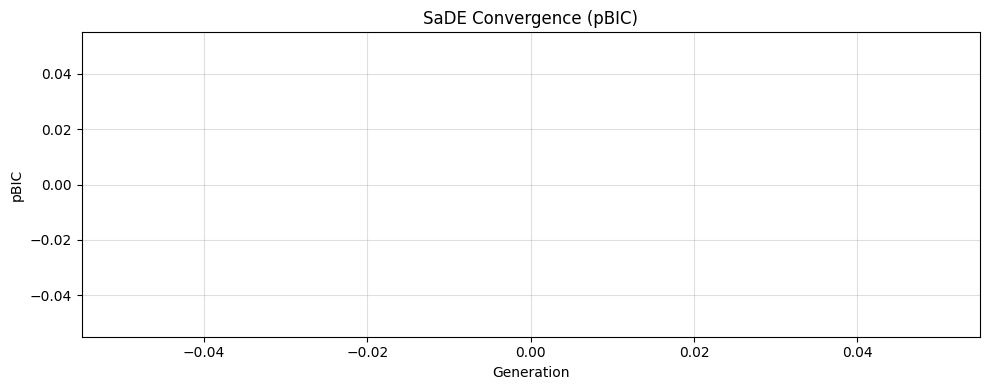


FIVE-MODEL COMPARISON
  pBIC = partial-likelihood BIC (Cox models, uses n_events)
  fBIC = full-likelihood BIC (Weibull AFT, uses n_total)
  NOTE: IBS_train is in-sample (optimistic). Run simulation
        study for out-of-bag IBS on unseen data.

[1/5] Fitting Kaplan-Meier...
   Median survival time : 3395.0000
   IBS_train            : 0.1953

[2/5] Fitting Traditional Cox PH...
   C-index : 0.8428   pAIC : 1526.28   pBIC : 1557.09   IBS_train : 0.1343

[3/5] Fitting Weibull AFT...
   C-index : 0.8426   AIC : 2845.49   fBIC : 2893.92   IBS_train : 0.1367
   NOTE: fBIC is NOT comparable to Cox pBIC values.

[4/5] Fitting MFP Cox (standard 8-power grid)...

  MFP converged in 4 cycle(s)
  alpha_select=0.05, alpha_function=0.05
  Power set |S| = 8
  Ranked order (by FP1 Wald): ['log_bili', 'age', 'albumin', 'protime', 'stage', 'log_copper', 'log_ast', 'log_trig', 'log_alk_phos', 'log_chol']
    log_bili              : FP1       powers=(0, None)  [fp2_vs_null=0.0000  fp2_vs_lin=0.0016 

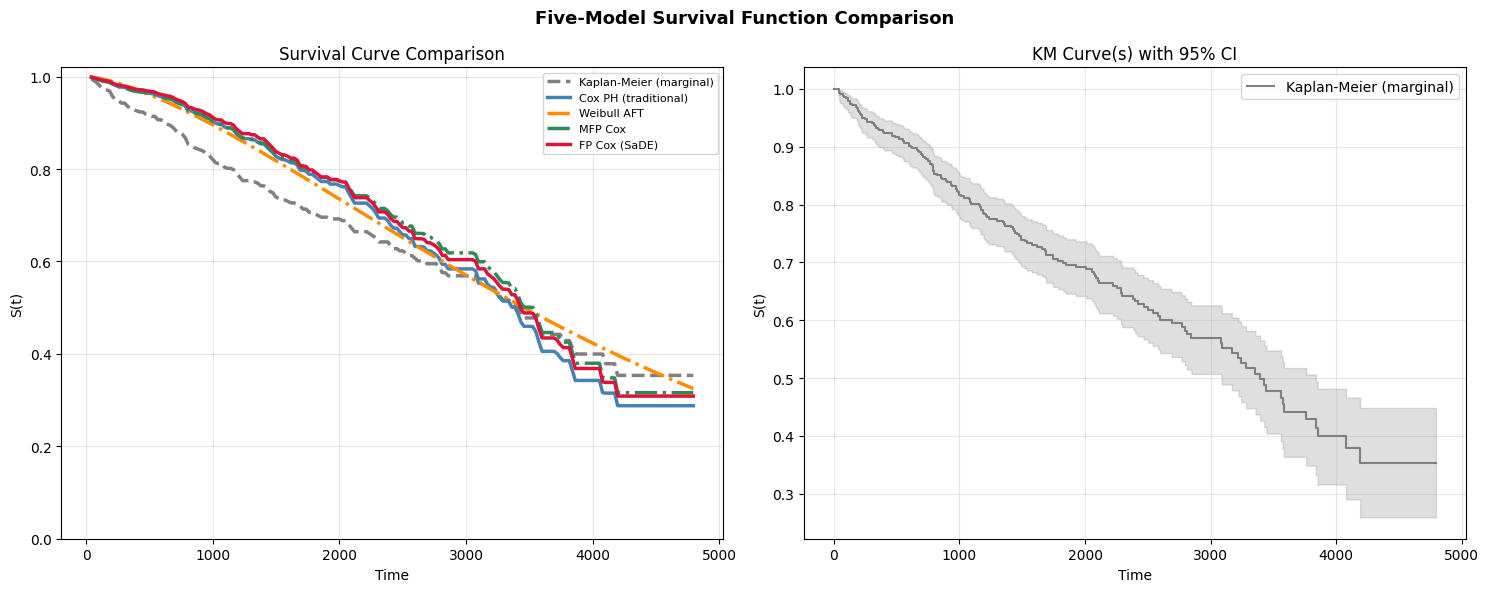


MODEL EQUATIONS

-- 1. KAPLAN-MEIER (non-parametric) --
  S(t) = prod_{ti <= t} (1 - di/ni)

-- 2. TRADITIONAL COX PH --
  log[h(t|x)/h0(t)] =
    + 0.340657 * age
    - 0.716824 * albumin
    + 0.195899 * protime
    + 0.395355 * stage
    + 1.084941 * log_bili
    - 0.071210 * log_chol
    + 0.305456 * log_copper
    - 0.010205 * log_alk_phos
    + 0.382642 * log_ast
    - 0.311545 * log_trig

-- 3. WEIBULL AFT --
  log T = mu(x) + sigma*eps,  eps ~ Gumbel
    - 0.228561 * age
    + 0.451901 * albumin
    - 0.027775 * log_alk_phos
    - 0.263794 * log_ast
    - 0.702934 * log_bili
    + 0.082715 * log_chol
    - 0.207021 * log_copper
    + 0.186395 * log_trig
    - 0.148858 * protime
    - 0.263672 * stage
    + 12.139455 * Intercept

-- 4. MFP COX --
  log[h(t|x)/h0(t)] =
    + 0.354223 * age_mfp_1
    - 0.913516 * albumin_mfp_1
    + 0.097942 * protime_mfp1_2
    - 0.004685 * protime_mfp2_3
    + 1.624478 * log_bili_mfp_0

-- 5. FP COX (SaDE) --
  log[h(t|x)/h0(t)] =
    + 4.47195

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
         test_name = proportional_hazard_test

---
                   test_statistic      p  -log2(p)
age          km              1.51   0.22      2.19
             rank            1.30   0.25      1.98
albumin      km              1.33   0.25      2.01
             rank            1.42   0.23      2.10
log_alk_phos km              0.15   0.70      0.52
             rank            0.40   0.53      0.92
log_ast      km              1.34   0.25      2.01
             rank            0.68   0.41      1.28
log_bili     km              0.08   0.78      0.36
             rank            0.02   0.88      0.19
log_chol     km              3.43   0.06      3.96
             rank            6.47   0.01      6.51
log_copper   km              1.04   0.31      1.70
             rank            1.28   0.26      1.96
log_trig     km              0.43   0.51      0.97
             rank            0.38   0.54      0.90
protime      km              7.92 <0.005      7.67
             rank            8.10 <0.005      7.82
stage        km              0.51   0.48      1.07
             rank            0.36   0.55      0.87



1. Variable 'protime' failed the non-proportional test: p-value is 0.0044.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'log_chol' failed the non-proportional test: p-value is 0.0110.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


  [B] Pearson rho(Schoenfeld residual, ranked event time):
  age                                    rho=-0.1282  p=0.1050
  albumin                                rho=-0.0668  p=0.3996
  protime                                rho=-0.0772  p=0.3303
  stage                                  rho=-0.0531  p=0.5032
  log_bili                               rho=-0.0196  p=0.8049
  log_chol                               rho=-0.0663  p=0.4036
  log_copper                

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic    p  -log2(p)
age_fp1_1           km              0.35 0.55      0.85
                    rank            0.55 0.46      1.12
age_fp2_rep_1       km              0.41 0.52      0.94
                    rank            0.62 0.43      1.21
albumin_fp1_-0.5    km              0.05 0.81      0.30
                    rank            0.27 0.61      0.72
albumin_fp2_1.5     km              0.00 0.97      0.04
                    rank            0.09 0.76      0.39
log_alk_phos_fp1_0  km              0.24 0.63      0.67
                    rank            0.28 0.59      0.75
log_alk_phos_fp2_3  km              0.31 0.58      0.80
                    rank            0.42 0.52      0.95
log_ast_fp1_-1.5    km              2.65 0.10      3.28
                    rank            2.05 0.15      2.71
log_ast_fp2_0.5     km              3.17 0.07      3.74
                    rank            2.42 0.12      3.06
log_bili_fp1_-3     km              0.34 0.56      0.83
                    rank            0.93 0.34      1.57
log_bili_fp2_0.25   km              0.64 0.42      1.23
                    rank            0.66 0.42      1.27
log_chol_fp1_-2     km              1.44 0.23      2.12
                    rank            2.32 0.13      2.97
log_chol_fp2_2      km              0.58 0.45      1.17
                    rank            0.84 0.36      1.47
log_copper_fp_-0.25 km              0.80 0.37      1.43
                    rank            0.98 0.32      1.63
log_trig_fp_0       km              0.05 0.82      0.29
                    rank            0.12 0.73      0.45
protime_fp_-0.5     km              5.51 0.02      5.73
                    rank            6.22 0.01      6.31
stage_fp1_-2        km              0.59 0.44      1.17
                    rank            0.49 0.48      1.05
stage_fp2_2.5       km              0.62 0.43      1.22
                    rank            0.28 0.60      0.74



1. Variable 'protime_fp_-0.5' failed the non-proportional test: p-value is 0.0126.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


  [B] Pearson rho(Schoenfeld residual, ranked event time):
  age_fp1_1                              rho=-0.1188  p=0.1334
  age_fp2_rep_1                          rho=-0.1225  p=0.1215
  albumin_fp1_-0.5                       rho=+0.0304  p=0.7021
  albumin_fp2_1.5

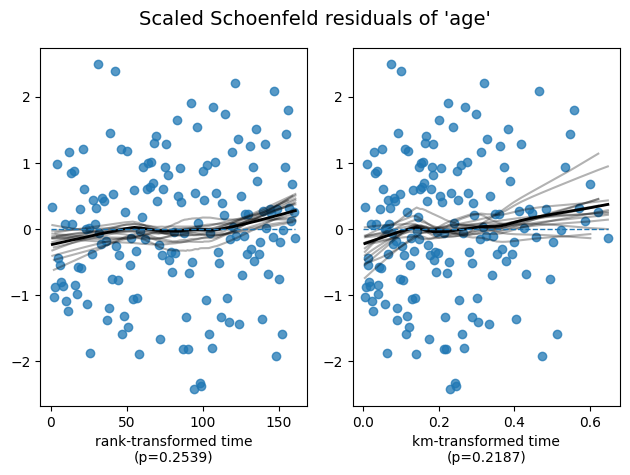

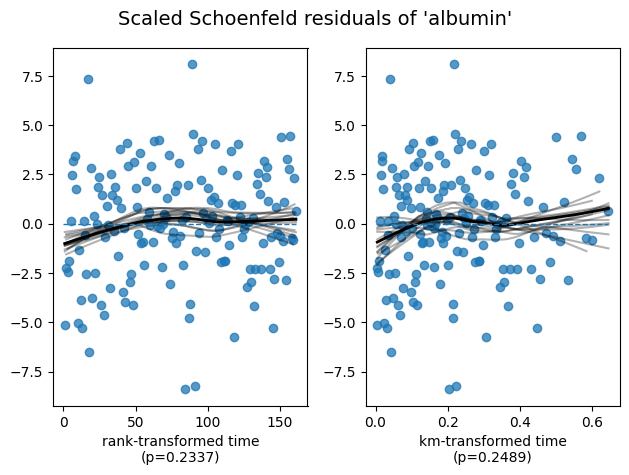

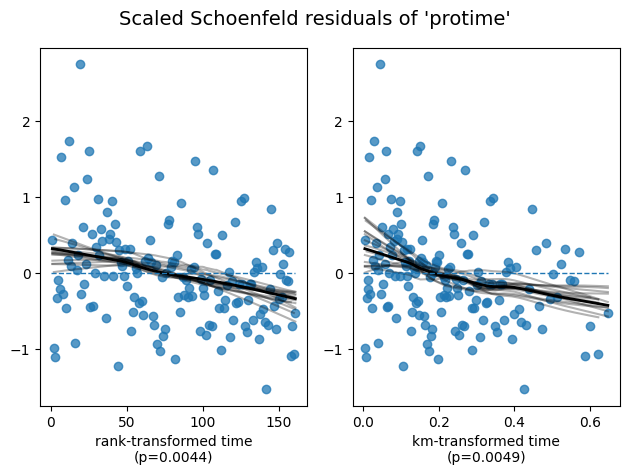

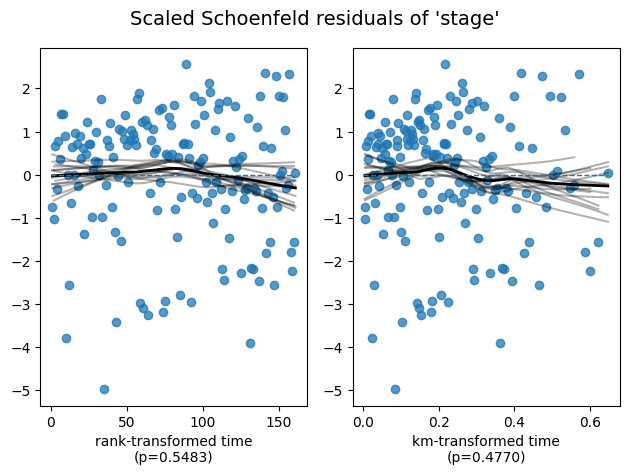

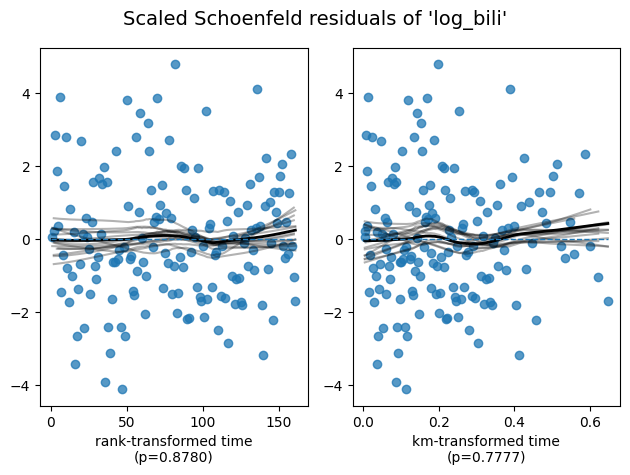

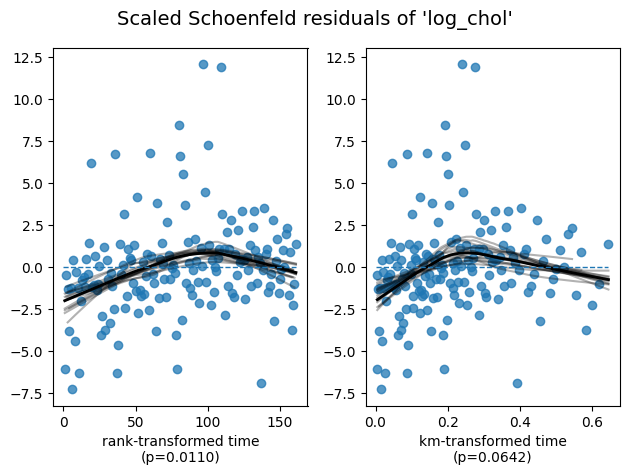

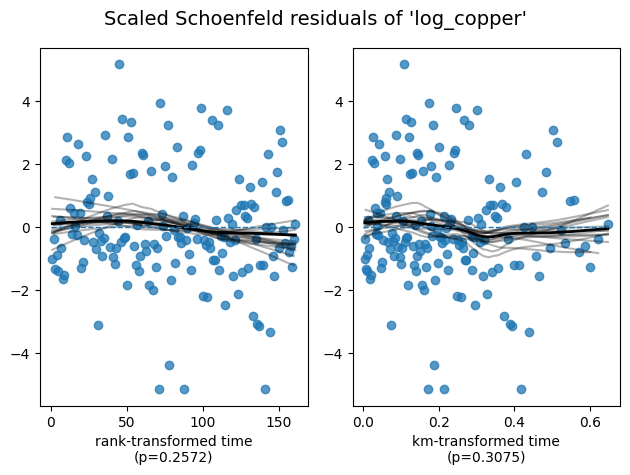

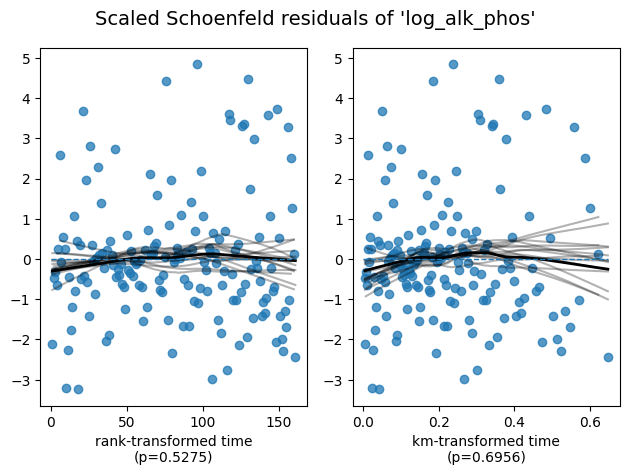

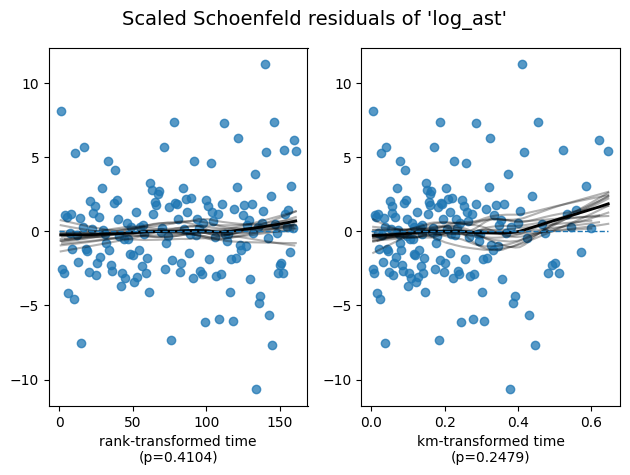

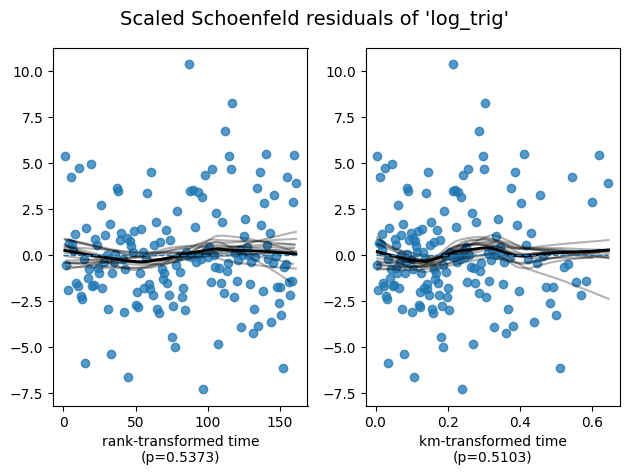

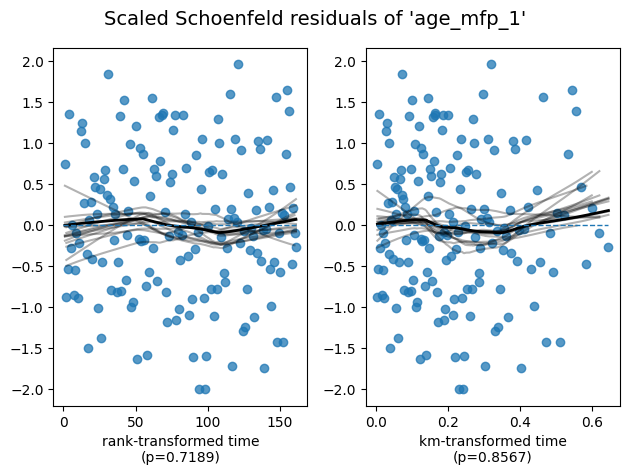

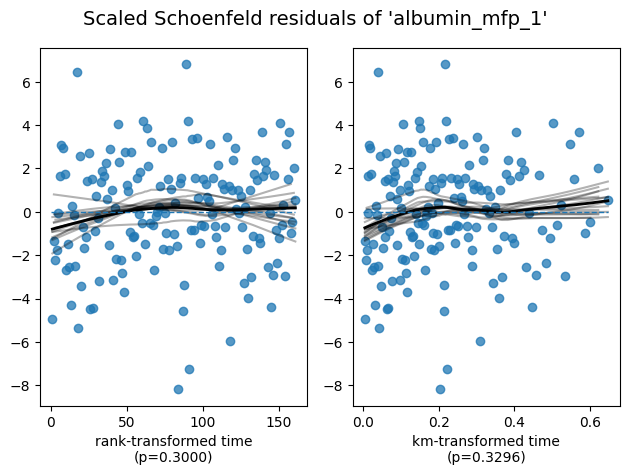

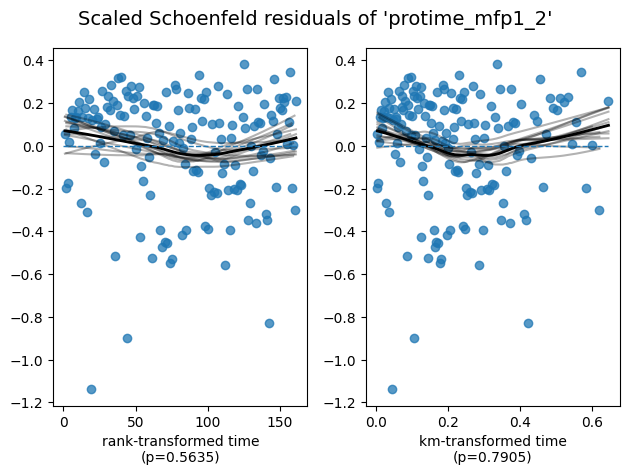

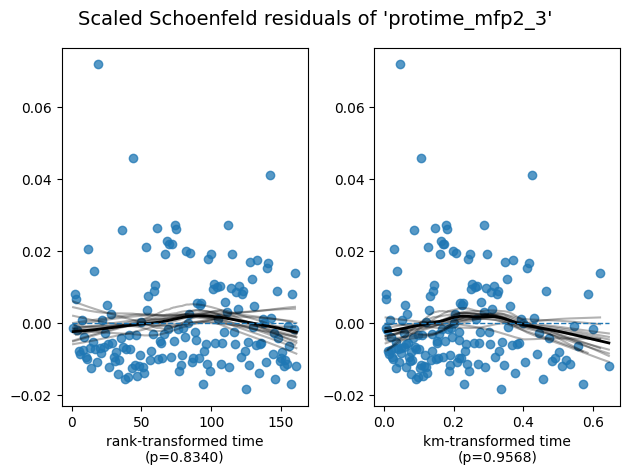

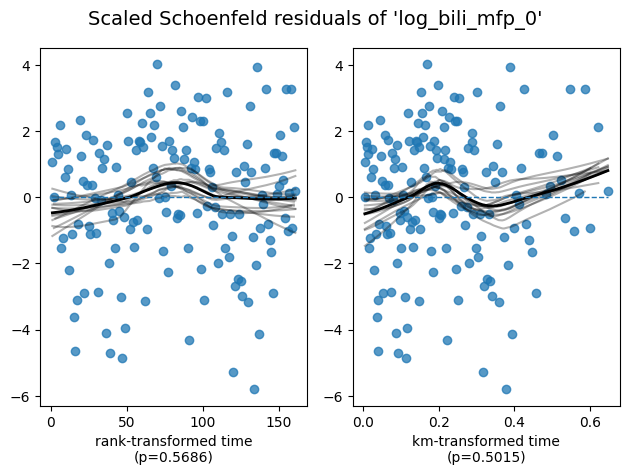

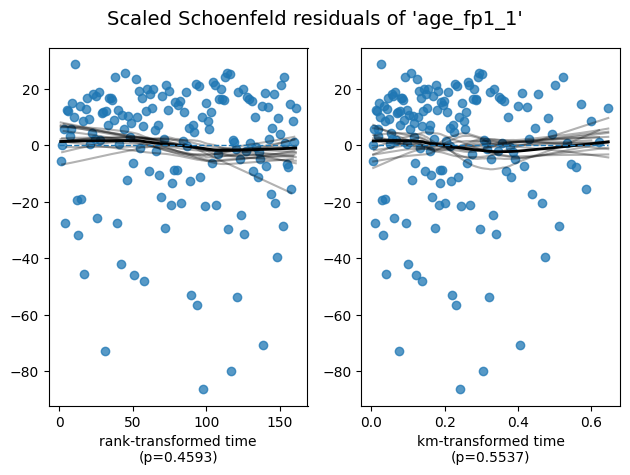

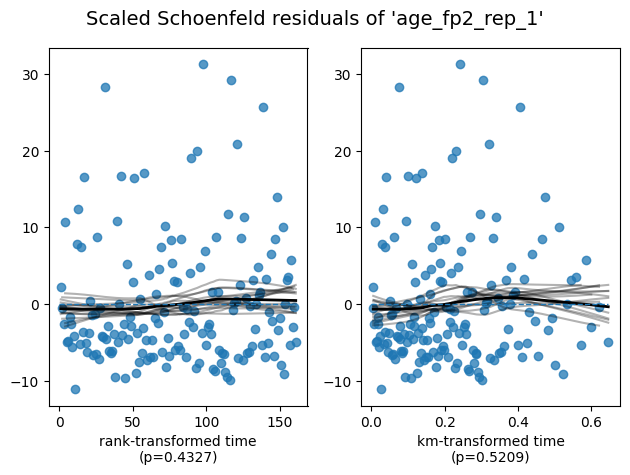

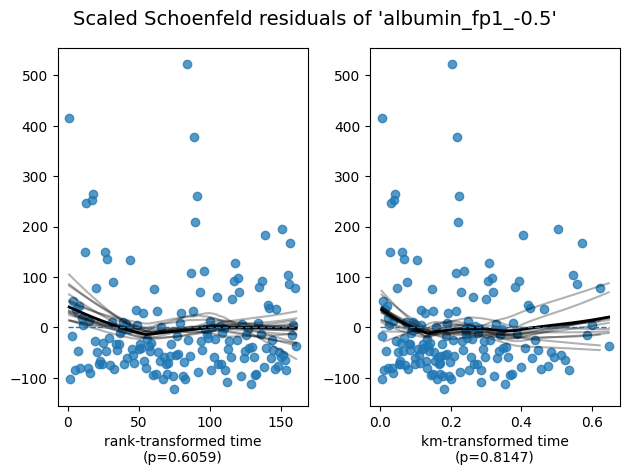

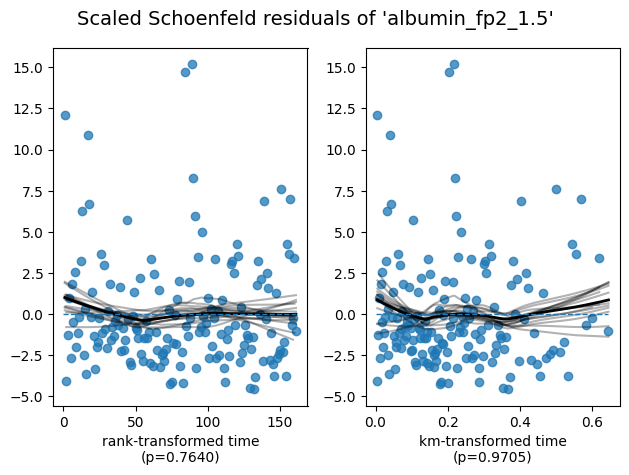

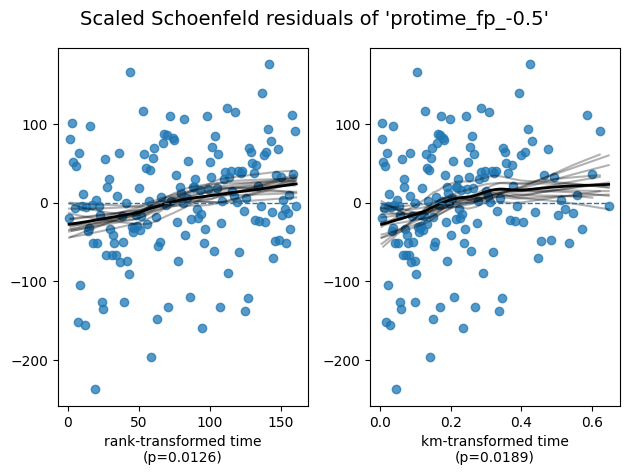

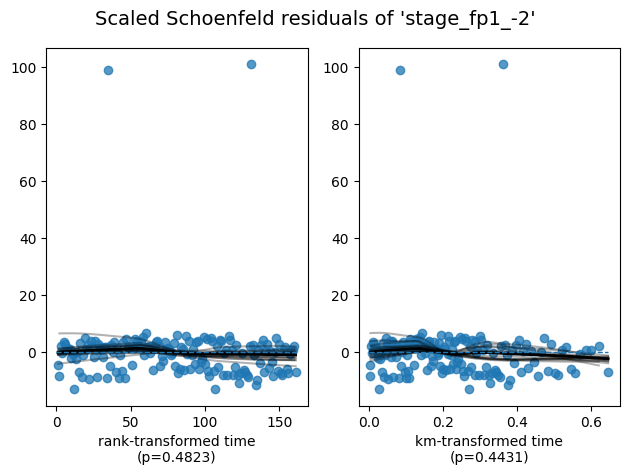

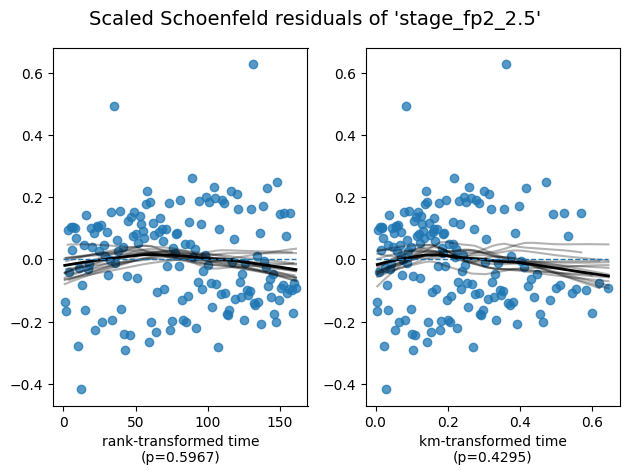

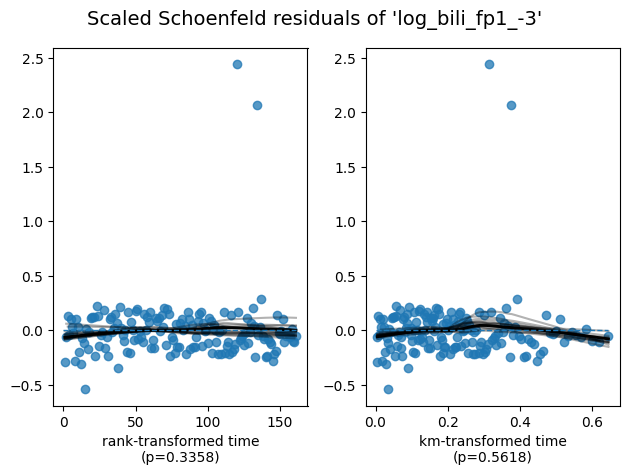

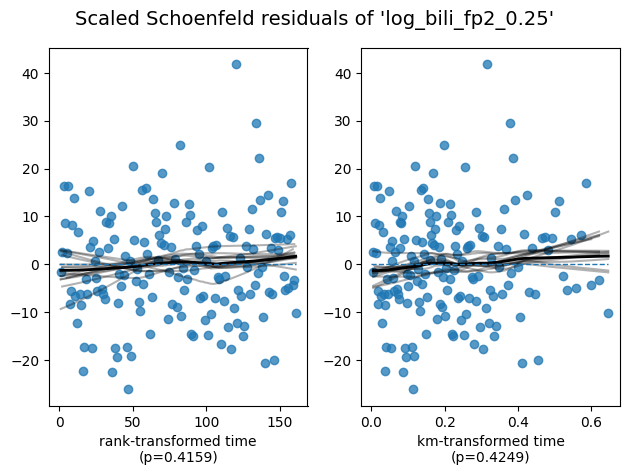

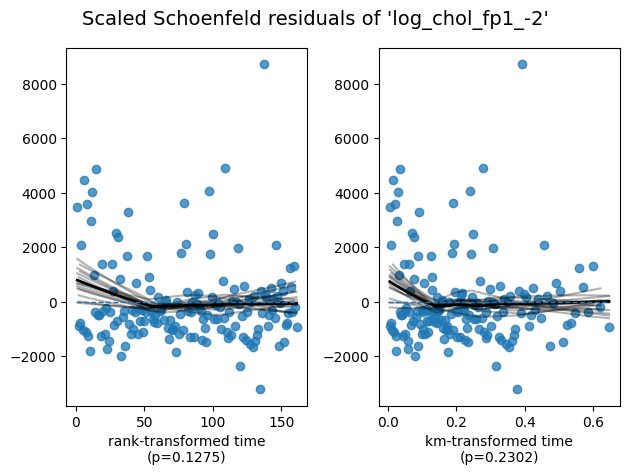

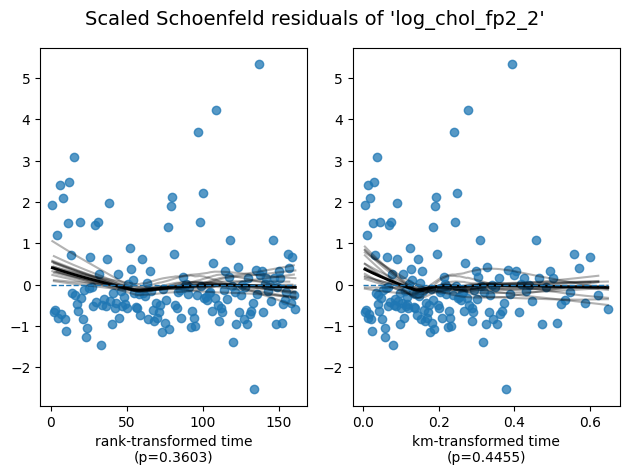

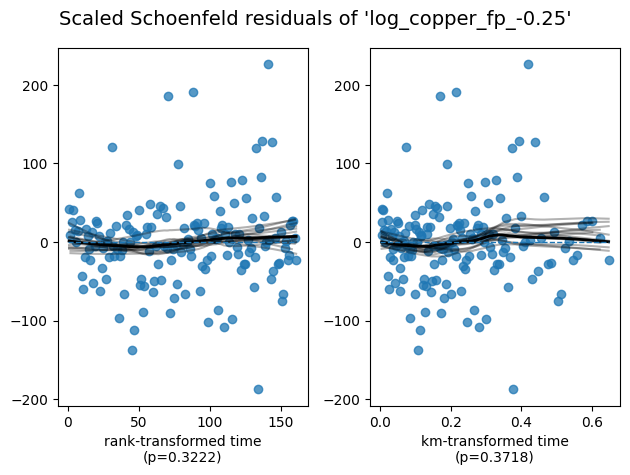

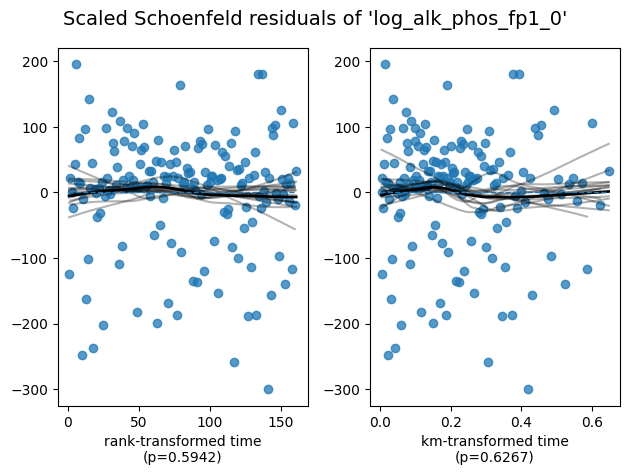

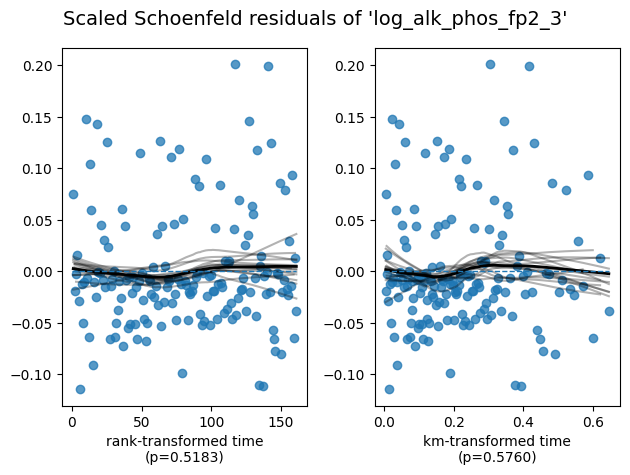

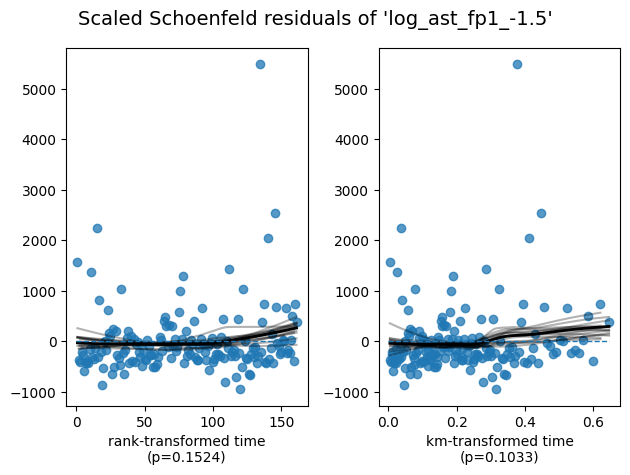

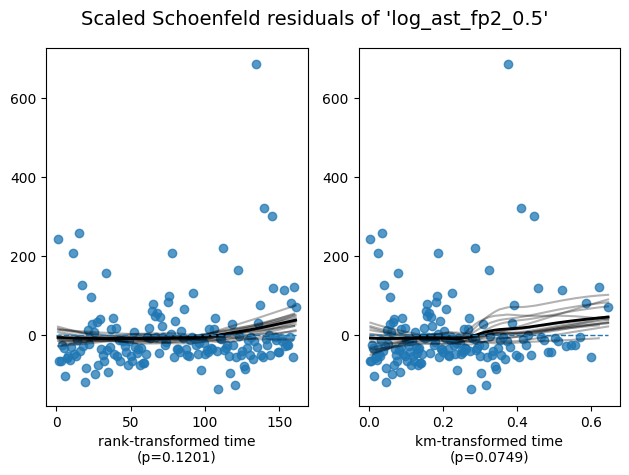

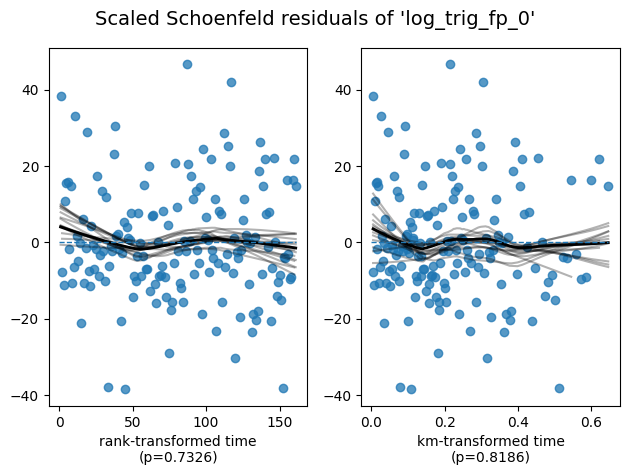

In [26]:
# -- Dataset 2: PBC --
pbc_df = pd.read_csv('../../../data/preprocess-data/preprocess_pbc.csv',
                     index_col=0)

PBC_COVARIATES = ['age', 'albumin', 'protime', 'stage',
                  'log_bili', 'log_chol', 'log_copper',
                  'log_alk_phos', 'log_ast', 'log_trig']
# PBC_STRATA     = ['edema'] strata_cols  = PBC_STRATA,

optimizer_pbc = FPCoxOptimizer(
    df           = pbc_df,
    covariates   = PBC_COVARIATES,
    duration_col = 'time',
    event_col    = 'status_binary',
)
optimizer_pbc.optimize(maxiter=1, seed=42)

# print('\nFP Cox model summary (PBC):')
# optimizer_pbc.final_fp_model.print_summary()

FP preprocessing (shift -> positive; scale is magnitude-only, does not affect deviance/BIC/C-index/IBS):
    log_pgr               : shift=+0.007775  scale=1
    log_er                : shift=+0.007043  scale=1
    age                   : shift=+0  scale=10
    size                  : shift=+0  scale=100
Starting SaDE v19  (pBIC with n_events; FP shift+scale applied)
  FP covariates : ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
  Simultaneous  : 5 covariates | dim=10
  n=686, n_events=299
  pBIC uses n_events=299 (Volinsky & Raftery 2000)
  Population sizing (data-adaptive):
    Target (15*D)    : 150
    Floor            : 40
    Cap              : 150
    -> NP chosen     : 150
  MaxGens=1 | Budget=150 | Patience=3

--- Optimal Power Selection ---
  log_pgr               : p1=0.5     p2=0.5      [FP2]
  log_nodes             : p1=-2.5    p2=-0.5     [FP2]
  log_er                : p1=-1      p2=None     [FP1]
  age                   : p1=-2      p2=-1       [FP2]
  size        

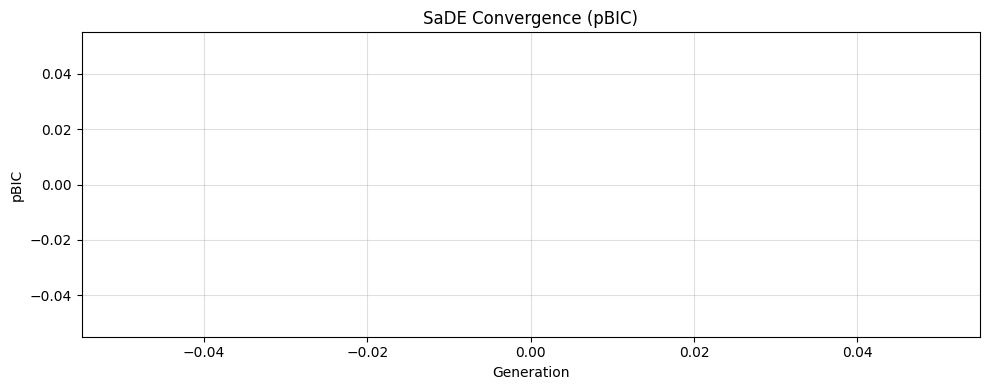


FIVE-MODEL COMPARISON
  pBIC = partial-likelihood BIC (Cox models, uses n_events)
  fBIC = full-likelihood BIC (Weibull AFT, uses n_total)
  NOTE: IBS_train is in-sample (optimistic). Run simulation
        study for out-of-bag IBS on unseen data.

[1/5] Fitting Kaplan-Meier...
   Median survival time : 1807.0000
   IBS_train            : 0.1950

[2/5] Fitting Traditional Cox PH...
   C-index : 0.6875   pAIC : 3466.94   pBIC : 3485.45   IBS_train : 0.1610

[3/5] Fitting Weibull AFT...
   C-index : 0.6870   AIC : 5161.61   fBIC : 5193.33   IBS_train : 0.1616
   NOTE: fBIC is NOT comparable to Cox pBIC values.

[4/5] Fitting MFP Cox (standard 8-power grid)...

  MFP converged in 2 cycle(s)
  alpha_select=0.05, alpha_function=0.05
  Power set |S| = 8
  Ranked order (by FP1 Wald): ['log_nodes', 'log_pgr', 'age', 'size', 'log_er']
    log_nodes             : linear    powers=(1, None)  [fp2_vs_null=0.0000  fp2_vs_lin=0.1752]
    log_pgr               : linear    powers=(1, None)  [fp2_vs_n

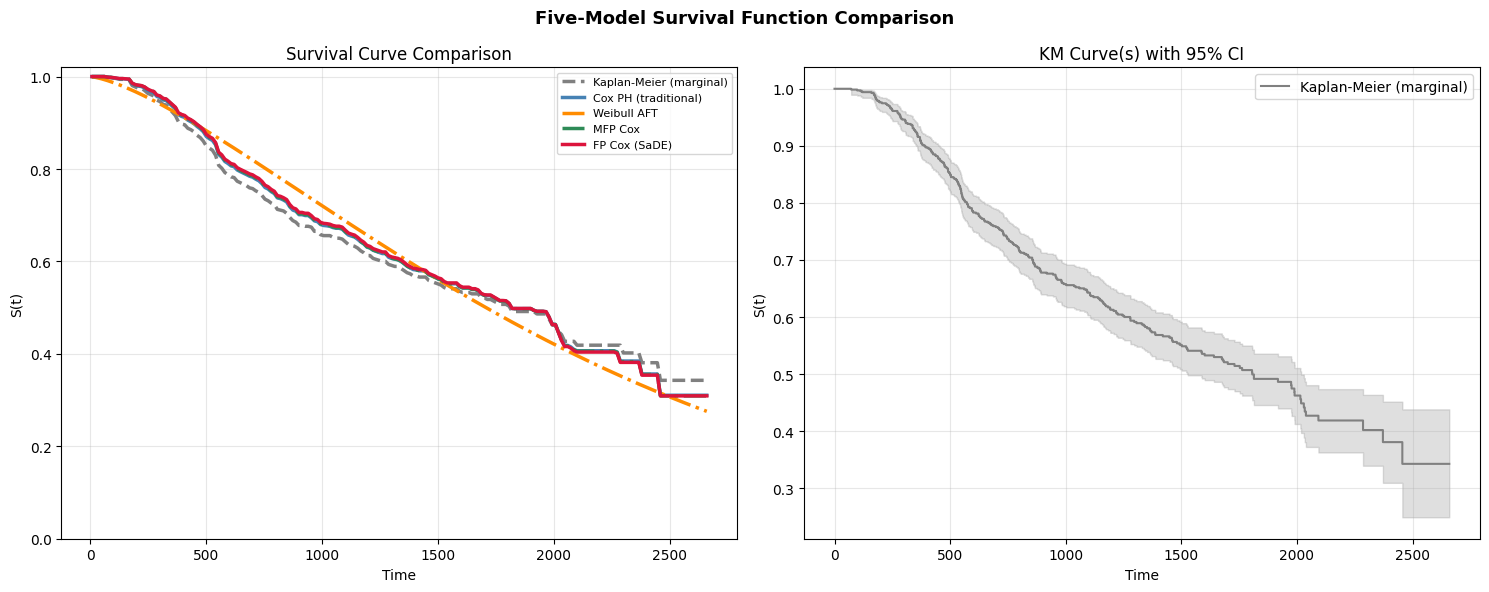


MODEL EQUATIONS

-- 1. KAPLAN-MEIER (non-parametric) --
  S(t) = prod_{ti <= t} (1 - di/ni)

-- 2. TRADITIONAL COX PH --
  log[h(t|x)/h0(t)] =
    - 0.210063 * log_pgr
    + 0.631964 * log_nodes
    + 0.021659 * log_er
    - 0.042958 * age
    + 0.363724 * size

-- 3. WEIBULL AFT --
  log T = mu(x) + sigma*eps,  eps ~ Gumbel
    + 0.025519 * age
    - 0.015703 * log_er
    - 0.472013 * log_nodes
    + 0.151375 * log_pgr
    - 0.280927 * size
    + 7.908359 * Intercept

-- 4. MFP COX --
  log[h(t|x)/h0(t)] =
    - 0.197243 * log_pgr_mfp_1
    + 0.663881 * log_nodes_mfp_1
    + 57.387456 * age_mfp1_-2
    - 23.996790 * age_mfp2_-1

-- 5. FP COX (SaDE) --
  log[h(t|x)/h0(t)] =
    + 0.112515 * log_pgr_fp1_0.5
    - 0.275829 * log_pgr_fp2_rep_0.5
    + 0.840741 * log_nodes_fp1_-2.5
    - 5.411648 * log_nodes_fp2_-0.5
    - 0.000081 * log_er_fp_-1
    + 61.295928 * age_fp1_-2
    - 25.578034 * age_fp2_-1
    - 0.017009 * size_fp_-1.5

  FP Power Annotation:
    log_pgr  [FP2]
      term 1:

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
                test_statistic      p  -log2(p)
age       km              7.71   0.01      7.51
          rank            8.17 <0.005      7.88
log_er    km              2.28   0.13      2.93
          rank            2.12   0.15      2.78
log_nodes km              0.53   0.47      1.10
          rank            0.75   0.38      1.38
log_pgr   km              0.28   0.60      0.74
          rank            0.47   0.49      1.03
size      km              0.05   0.83      0.27
          rank            0.04   0.84      0.25



1. Variable 'age' failed the non-proportional test: p-value is 0.0042.


   Bootstrapping lowess lines. May take a moment...


  [B] Pearson rho(Schoenfeld residual, ranked event time):
  log_pgr                                rho=-0.0614  p=0.2901
  log_nodes                              rho=+0.0422  p=0.4671
  log_er                                 rho=-0.0234  p=0.6876
  age                                    rho=+0.0525  p=0.3655
  size                                   rho=+0.0023  p=0.9678
  OK: No strong evidence of PH violation.
----------------------------------------------------------------

----------------------------------------------------------------
  PH ASSUMPTION TEST - MFP Cox (trad FP)
----------------------------------------------------------------

  [A] lifelines check_assumptions():

   Bootstrapping lowess lines. May take a moment...



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
                      test_statistic    p  -log2(p)
age_mfp1_-2     km              2.53 0.11      3.16
                rank            2.80 0.09      3.41
age_mfp2_-1     km              3.87 0.05      4.35
                rank            4.21 0.04      4.64
log_nodes_mfp_1 km              0.58 0.45      1.16
                rank            0.82 0.36      1.46
log_pgr_mfp_1   km              4.36 0.04      4.76
                rank            5.03 0.02      5.33



1. Variable 'log_pgr_mfp_1' failed the non-proportional test: p-value is 0.0249.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'age_mfp2_-1' failed the non-proportional test: p-value is 0.0402.


  [B] Pearson rho(Schoenfeld residual, ranked event time):
  log_pgr_mfp_1                          rho=-0.0612  p=0.2914
  log_nodes_mfp_1                        rho=+0.0437  p=0.4519
  age_mfp1_-2                            rho=-0.0384  p=0.5078
  age_mfp2_-1                            rho=-0.0422  p=0.4676
  OK: No strong evidence of PH violation.
----------------------------------------------------------------

----------------------------------------------------------------
  PH ASSUMPTION TEST - FP Cox (SaDE)
----------------------------------------------------------------

  [A] lifelines check_assumptions():

   Bootstrapping lowess lines. May take a momen

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic    p  -log2(p)
age_fp1_-2          km              2.46 0.12      3.09
                    rank            2.80 0.09      3.40
age_fp2_-1          km              3.62 0.06      4.13
                    rank            4.00 0.05      4.46
log_er_fp_-1        km              0.18 0.67      0.57
                    rank            0.12 0.73      0.45
log_nodes_fp1_-2.5  km              0.00 0.95      0.07
                    rank            0.09 0.77      0.38
log_nodes_fp2_-0.5  km              0.12 0.73      0.45
                    rank            0.04 0.85      0.24
log_pgr_fp1_0.5     km              1.07 0.30      1.73
                    rank            1.16 0.28      1.83
log_pgr_fp2_rep_0.5 km              2.85 0.09      3.45
                    rank            3.28 0.07      3.83
size_fp_-1.5        km              0.56 0.45      1.14
                    rank            0.64 0.42      1.23



1. Variable 'age_fp2_-1' failed the non-proportional test: p-value is 0.0454.


   Bootstrapping lowess lines. May take a moment...


  [B] Pearson rho(Schoenfeld residual, ranked event time):
  log_pgr_fp1_0.5                        rho=-0.0420  p=0.4696
  log_pgr_fp2_rep_0.5                    rho=-0.0619  p=0.2857
  log_nodes_fp1_-2.5                     rho=+0.0216  p=0.7101
  log_nodes_fp2_-0.5                     rho=-0.0087  p=0.8808
  log_er_fp_-1                           rho=-0.0058  p=0.9204
  age_fp1_-2                             rho=-0.0383  p=0.5091
  age_fp2_-1                             rho=-0.0421  p=0.4684
  size_fp_-1.5                           rho=-0.0480  p=0.4086
  OK: No strong evidence of PH violation.
----------------------------------------------------------------


TIERED MODEL COMPARISON

--------------------------------------------------------------------------------
  TIER 1 — Universal metrics (all 5 models)
  These metrics are comparable across ALL 

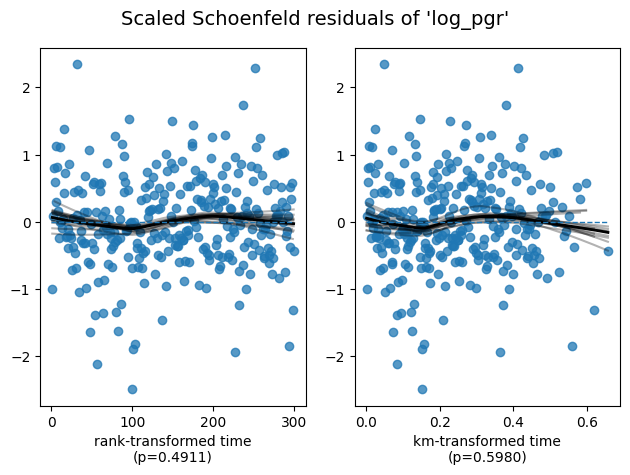

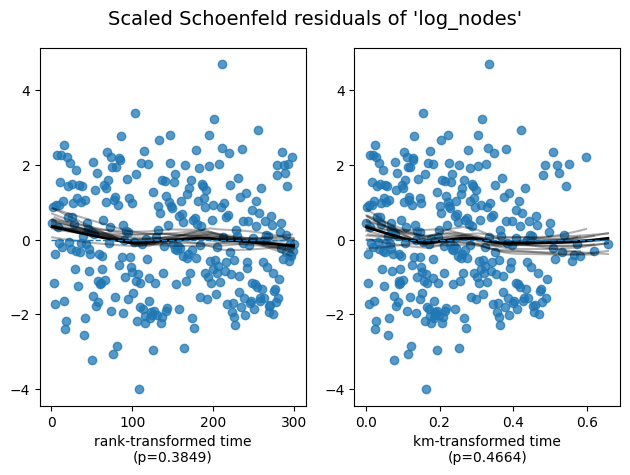

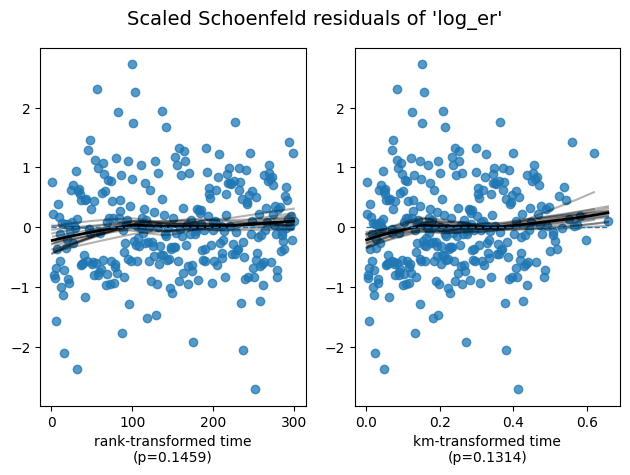

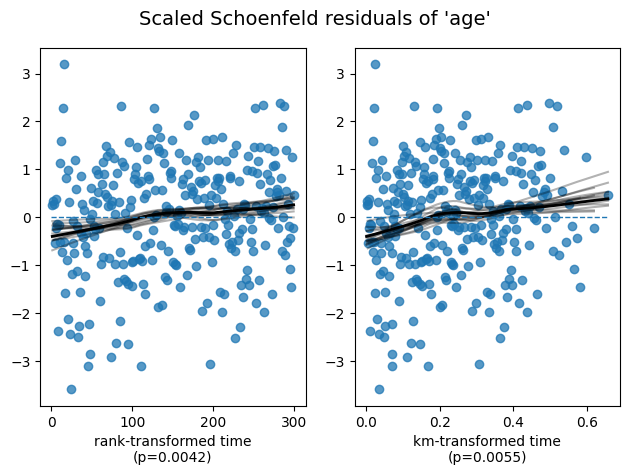

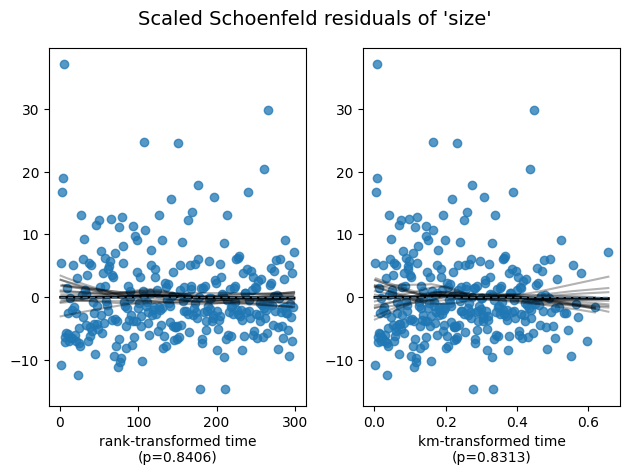

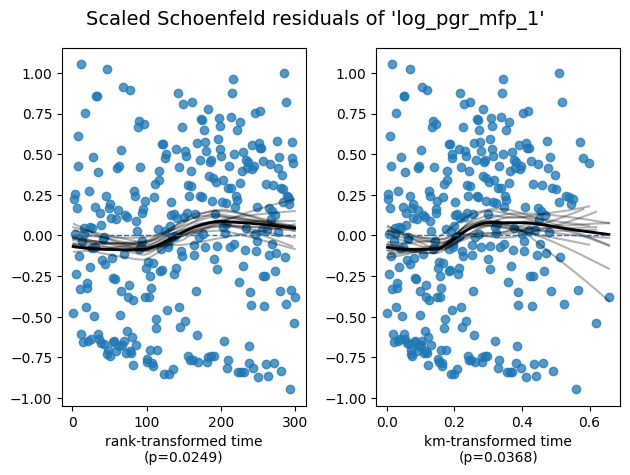

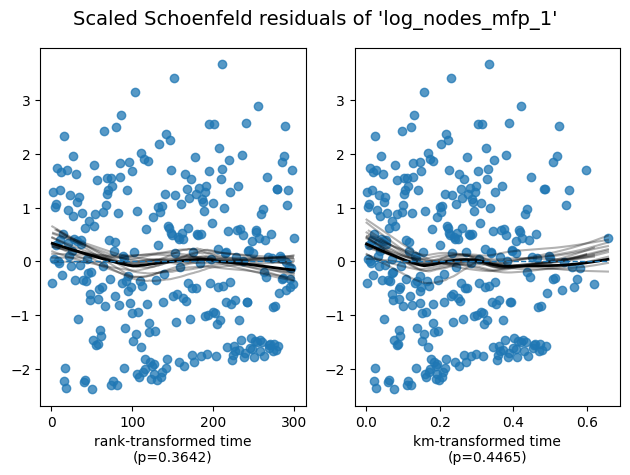

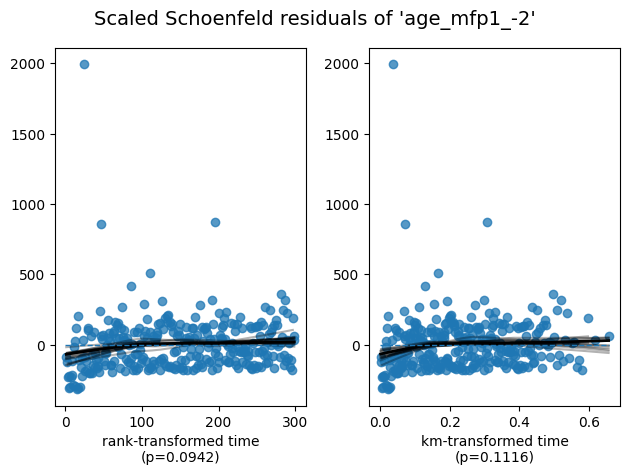

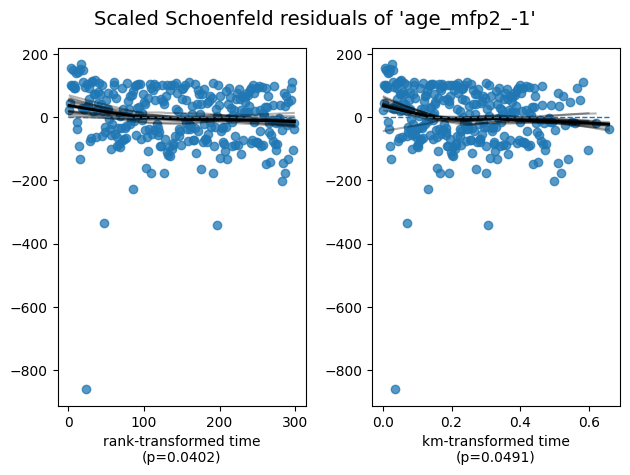

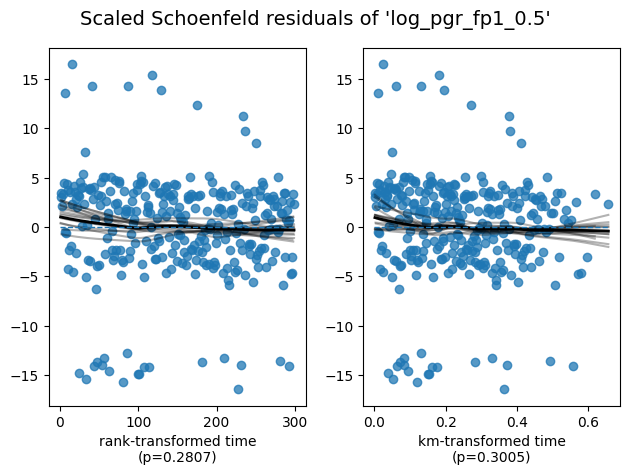

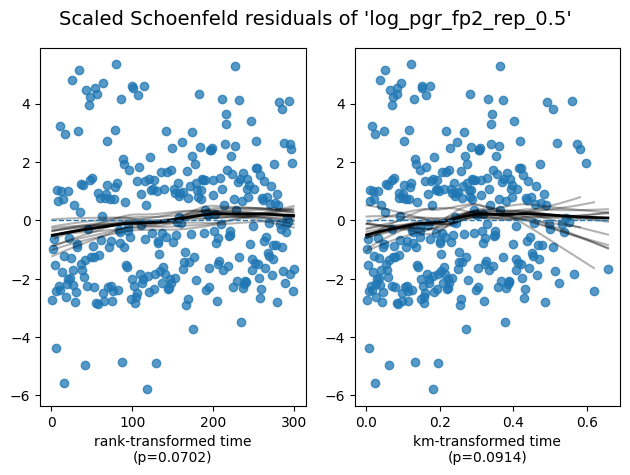

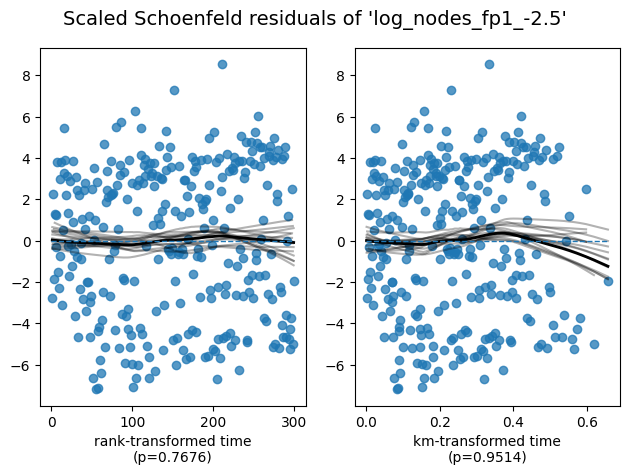

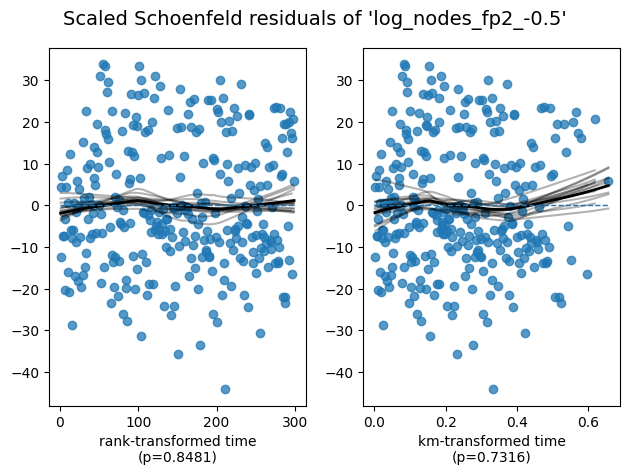

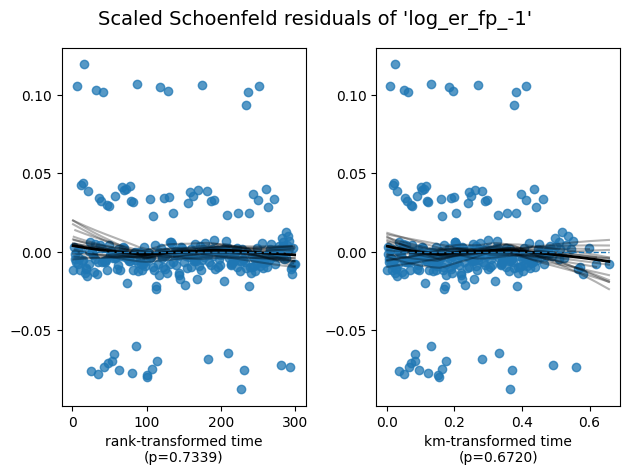

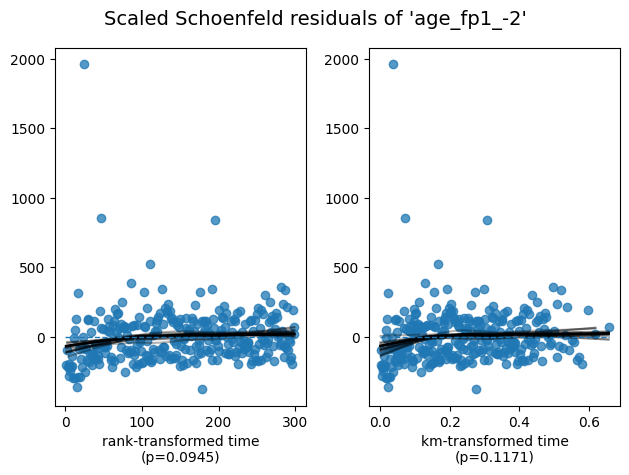

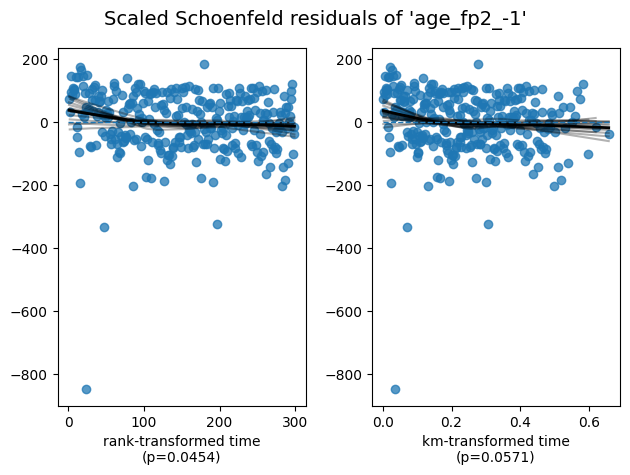

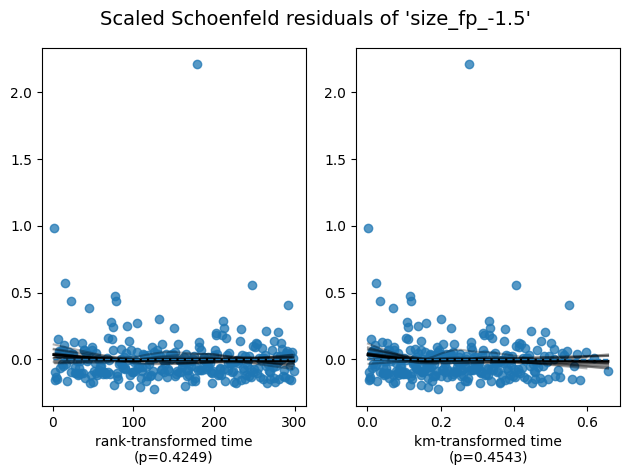

In [27]:
# -- Dataset 3: GBSG --
gb_df = pd.read_csv('../../../data/preprocess-data/preprocess_gbsg.csv')

GB_COVARIATES = ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
# GB_STRATA     = ['meno', 'grade', 'hormon'] strata_cols  = GB_STRATA,

optimizer_gb = FPCoxOptimizer(
    df           = gb_df,
    covariates   = GB_COVARIATES,
    duration_col = 'rfstime',
    event_col    = 'status',
)
optimizer_gb.optimize(maxiter=1, seed=42)

# print('\nFP Cox model summary (GBSG):')
# optimizer_gb.final_fp_model.print_summary()

## Bootstrap Internal Validation (out-of-bag)

> This is **internal validation by bootstrap resampling**, not a Monte-Carlo simulation: no synthetic data is generated from a known model. It estimates out-of-bag predictive performance and the stability of power selection, so describe it as internal validation (not a "simulation study") in the write-up.

**Key features:**
- True bootstrap (sample WITH replacement) — FIX #6
- OOB samples form the holdout (~36.8% unique holdout on average)
- Holdout IBS uses correct IPCW from training censoring distribution — FIX #7
- `reselect_powers=True` re-runs SaDE + MFP on each bootstrap sample — FIX #10
- No internal preprocessing — data used as-is (v16)

### Two simulation modes:
1. `reselect_powers=False` (fast): Fixed powers, captures coefficient estimation variability only.
2. `reselect_powers=True` (slow): Full pipeline re-selection, captures total modeling uncertainty.

Run mode 1 first for quick results, then mode 2 for the full picture.

**OOB IBS** (`*_ibs_test`) is the primary metric for unseen-data calibration.


In [28]:
# -- Simulation: Simulated dataset (fixed powers) --
# sim_results_sd = optimizer_sd.run_simulation_study(
#     n_sims              = 500,
#     seed                = 42,
#     show_progress_every = 100,
#     reselect_powers     = False,
# )

In [29]:
# -- Simulation: PBC (fixed powers) --
# sim_results_pbc = optimizer_pbc.run_simulation_study(
#     n_sims              = 500,
#     seed                = 42,
#     show_progress_every = 100,
#     reselect_powers     = False,
# )

In [30]:
# -- Simulation: GBSG (fixed powers) --
# sim_results_gb = optimizer_gb.run_simulation_study(
#     n_sims              = 500,
#     seed                = 42,
#     show_progress_every = 100,
#     reselect_powers     = False,
# )

In [31]:
# -- Simulation with power re-selection (FIX #10) --
# WARNING: This is much slower (re-runs SaDE per iteration).
# Reduce n_sims for initial testing.

# sim_results_sd_reselect = optimizer_sd.run_simulation_study(
#     n_sims              = 500,
#     seed                = 42,
#     show_progress_every = 100,
#     reselect_powers     = True,
#     sade_maxiter_sim    = 1500,
#     n_jobs              = 4,
# )

In [ ]:
# -- PBC with power re-selection --
# sim_results_pbc_reselect = optimizer_pbc.run_simulation_study(
#     n_sims              = 500,
#     seed                = 42,
#     show_progress_every = 100,
#     reselect_powers     = True,
#     sade_maxiter_sim    = 1000,
#     n_jobs              = 6,
# )


BOOTSTRAP INTERNAL VALIDATION  (n_sims=500, sampling with replacement)
  Power re-selection: True
  Parallel: n_jobs=6 (1 native thread per worker)


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 103.8min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 211.7min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 483.9min
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed: 650.5min
[Parallel(n_jobs=6)]: Done  29 tasks      | elapsed: 941.6min
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed: 1100.2min
[Parallel(n_jobs=6)]: Done  49 tasks      | elapsed: 1427.6min


In [ ]:
# -- GBSG with power re-selection --
# sim_results_gb_reselect = optimizer_gb.run_simulation_study(
#     n_sims              = 500,
#     seed                = 42,
#     show_progress_every = 100,
#     reselect_powers     = True,
#     sade_maxiter_sim    = 1000,
#     n_jobs              = 6,
# )

### Simulated dataset

In [1]:
sim_nl_df = pd.read_csv('../../../data/preprocess-data/preprocess_sim_nonlinear.csv')

optimizer_sim_nl = FPCoxOptimizer(
    df           = sim_nl_df,
    covariates   = ['Age'],
    duration_col = 'Time',
    event_col    = 'Event',
)
optimizer_sim_nl.optimize(maxiter=1, seed=42)    # expect best_powers = (-2, None)

print('\nFP Cox model summary (Simulated NON-LINEAR):')
optimizer_sim_nl.final_fp_model.print_summary()

NameError: name 'pd' is not defined

In [ ]:
sim_results_nl_reselect = optimizer_sim_nl.run_simulation_study(
    n_sims              = 1000,
    seed                = 42,
    show_progress_every = 100,
    reselect_powers     = True,
    sade_maxiter_sim    = 30,
    n_jobs              = 6,
)